In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 1

In [ ]:
#A) Hadamard Coding in CDMA

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

In [2]:
# 1. Generate three user sequences m1[n], m2[n], m3[n] of length 8 with values in {-1, 1}
np.random.seed(42) # for reproducibility

sequence_length = 8
num_users = 3

# Generate random sequences of -1 and 1
# m_signals = []
# for i in range(num_users):
#     m_signals.append(np.random.choice([-1, 1], size=sequence_length))

# m1 = m_signals[0]
# m2 = m_signals[1]
# m3 = m_signals[2]

m1 = np.random.choice([-1, 1], size=sequence_length)
m2 = np.random.choice([-1, 1], size=sequence_length)
m3 = np.random.choice([-1, 1], size=sequence_length)


print(f"User 1 signal (m1): {m1}")
print(f"User 2 signal (m2): {m2}")
print(f"User 3 signal (m3): {m3}")

User 1 signal (m1): [-1  1 -1 -1 -1  1 -1 -1]
User 2 signal (m2): [-1  1 -1 -1 -1 -1  1 -1]
User 3 signal (m3): [ 1  1  1 -1  1 -1  1  1]


In [3]:
# 2. Generate a Hadamard code of length 8
H8 = hadamard(sequence_length)

# Choose 3 orthogonal codes for the users (e.g., first 3 rows)
# In CDMA, each user is assigned a unique orthogonal code.
code1 = H8[1] # Using row 1 as code for user 1
code2 = H8[2] # Using row 2 as code for user 2
code3 = H8[3] # Using row 3 as code for user 3

print(f"Hadamard matrix H8:\n{H8}")
print(f"Code for user 1: {code1}")
print(f"Code for user 2: {code2}")
print(f"Code for user 3: {code3}")

Hadamard matrix H8:
[[ 1  1  1  1  1  1  1  1]
 [ 1 -1  1 -1  1 -1  1 -1]
 [ 1  1 -1 -1  1  1 -1 -1]
 [ 1 -1 -1  1  1 -1 -1  1]
 [ 1  1  1  1 -1 -1 -1 -1]
 [ 1 -1  1 -1 -1  1 -1  1]
 [ 1  1 -1 -1 -1 -1  1  1]
 [ 1 -1 -1  1 -1  1  1 -1]]
Code for user 1: [ 1 -1  1 -1  1 -1  1 -1]
Code for user 2: [ 1  1 -1 -1  1  1 -1 -1]
Code for user 3: [ 1 -1 -1  1  1 -1 -1  1]


In [4]:
# 3. Encode the signals m1[n], m2[n], m3[n]
# Each bit of the user's data sequence is spread by the Hadamard code.
# This means if a data bit is 1, the code sequence is transmitted.
# If a data bit is -1, the inverted code sequence is transmitted.

# For simplicity, we are assuming a direct multiplication where m[n] is a sequence of bits.
# In a real system, each 'bit' of m[n] (which is -1 or 1) would modulate the entire code sequence.
# Here, we'll perform element-wise multiplication for the entire sequence's length.
# This is a simplified model, where the entire sequence m_i is spread by the code_i.

coded_signal_1 = np.zeros(sequence_length * sequence_length)
coded_signal_2 = np.zeros(sequence_length * sequence_length)
coded_signal_3 = np.zeros(sequence_length * sequence_length)

for i in range(sequence_length):
  start_index = i * sequence_length
  end_index = (i + 1) * sequence_length
  coded_signal_1[start_index:end_index] = m1[i]*code1
  coded_signal_2[start_index:end_index] = m2[i]*code2
  coded_signal_3[start_index:end_index] = m3[i]*code3

print(f"Coded signal for user 1: {coded_signal_1}")
print(f"Coded signal for user 2: {coded_signal_2}")
print(f"Coded signal for user 3: {coded_signal_3}")

Coded signal for user 1: [-1.  1. -1.  1. -1.  1. -1.  1.  1. -1.  1. -1.  1. -1.  1. -1. -1.  1.
 -1.  1. -1.  1. -1.  1. -1.  1. -1.  1. -1.  1. -1.  1. -1.  1. -1.  1.
 -1.  1. -1.  1.  1. -1.  1. -1.  1. -1.  1. -1. -1.  1. -1.  1. -1.  1.
 -1.  1. -1.  1. -1.  1. -1.  1. -1.  1.]
Coded signal for user 2: [-1. -1.  1.  1. -1. -1.  1.  1.  1.  1. -1. -1.  1.  1. -1. -1. -1. -1.
  1.  1. -1. -1.  1.  1. -1. -1.  1.  1. -1. -1.  1.  1. -1. -1.  1.  1.
 -1. -1.  1.  1. -1. -1.  1.  1. -1. -1.  1.  1.  1.  1. -1. -1.  1.  1.
 -1. -1. -1. -1.  1.  1. -1. -1.  1.  1.]
Coded signal for user 3: [ 1. -1. -1.  1.  1. -1. -1.  1.  1. -1. -1.  1.  1. -1. -1.  1.  1. -1.
 -1.  1.  1. -1. -1.  1. -1.  1.  1. -1. -1.  1.  1. -1.  1. -1. -1.  1.
  1. -1. -1.  1. -1.  1.  1. -1. -1.  1.  1. -1.  1. -1. -1.  1.  1. -1.
 -1.  1.  1. -1. -1.  1.  1. -1. -1.  1.]


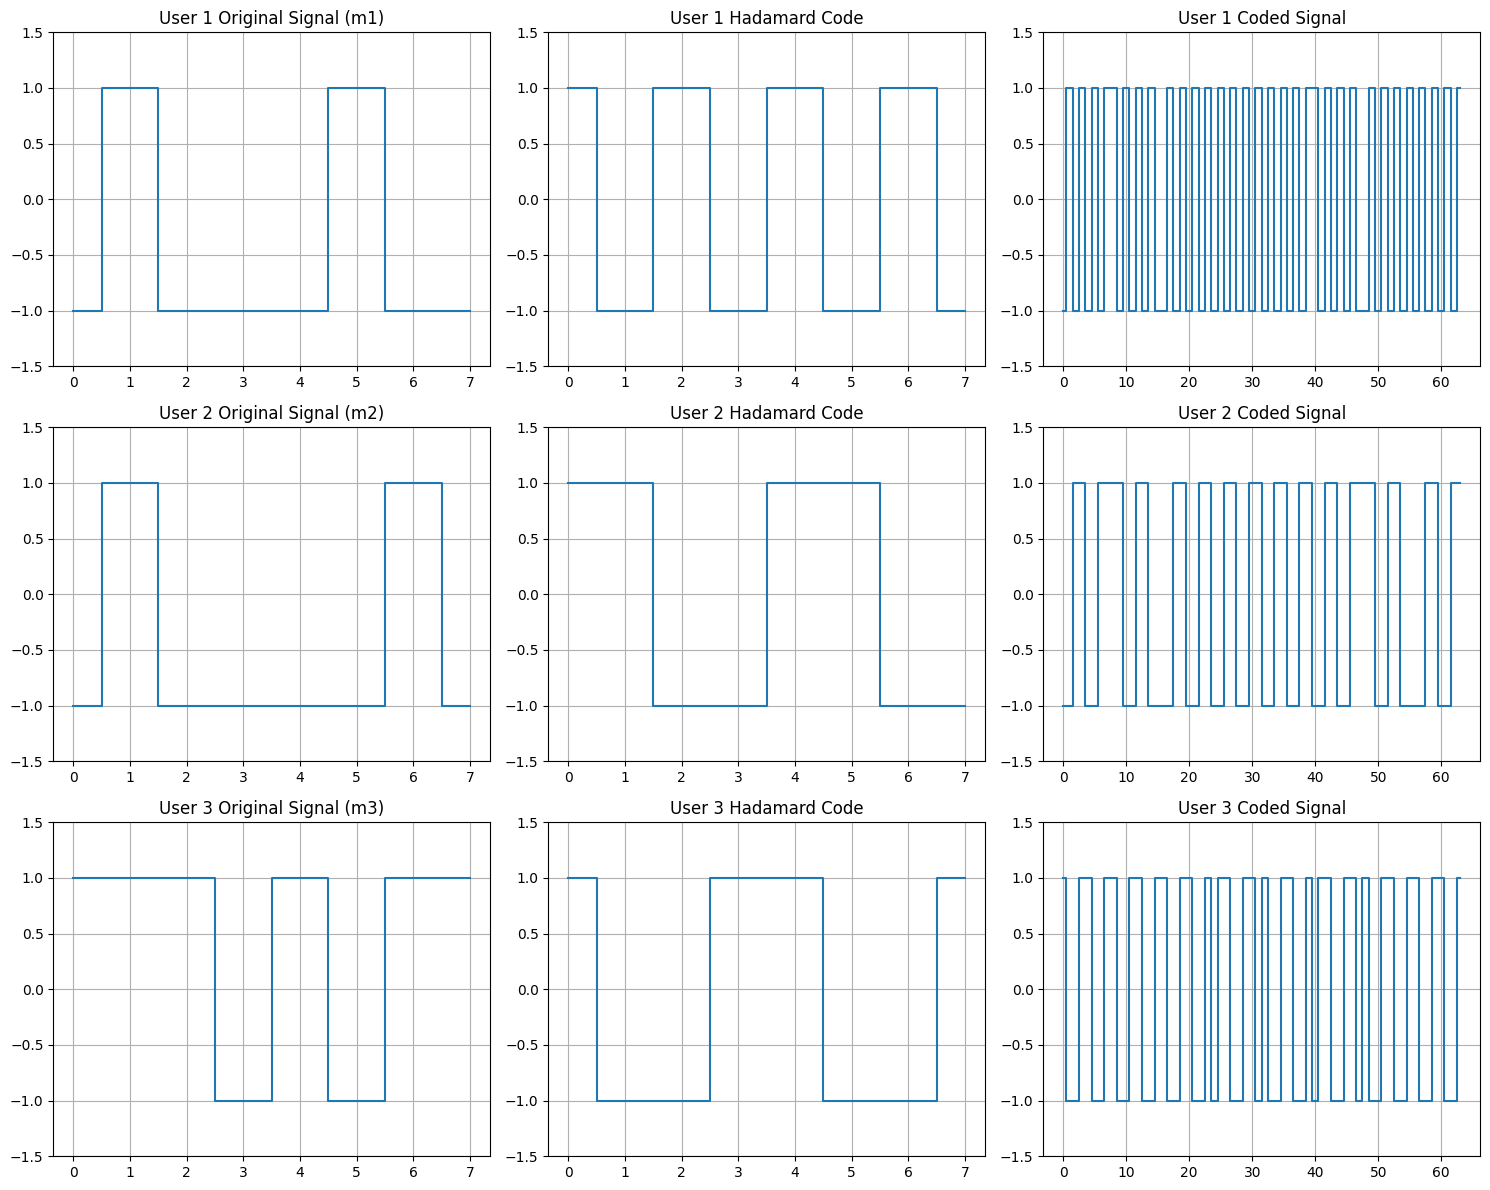

In [5]:
# 4. Plot the original signal, its code, and the coded signal for each user

plt.figure(figsize=(15, 12))

# User 1
plt.subplot(3, 3, 1)
plt.step(range(sequence_length), m1, where='mid')
plt.title('User 1 Original Signal (m1)')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 2)
plt.step(range(sequence_length), code1, where='mid')
plt.title('User 1 Hadamard Code')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 3)
plt.step(range(sequence_length*sequence_length), coded_signal_1, where='mid')
plt.title('User 1 Coded Signal')
plt.ylim(-1.5, 1.5)
plt.grid(True)

# User 2
plt.subplot(3, 3, 4)
plt.step(range(sequence_length), m2, where='mid')
plt.title('User 2 Original Signal (m2)')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 5)
plt.step(range(sequence_length), code2, where='mid')
plt.title('User 2 Hadamard Code')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 6)
plt.step(range(sequence_length*sequence_length), coded_signal_2, where='mid')
plt.title('User 2 Coded Signal')
plt.ylim(-1.5, 1.5)
plt.grid(True)

# User 3
plt.subplot(3, 3, 7)
plt.step(range(sequence_length), m3, where='mid')
plt.title('User 3 Original Signal (m3)')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 8)
plt.step(range(sequence_length), code3, where='mid')
plt.title('User 3 Hadamard Code')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 9)
plt.step(range(sequence_length*sequence_length), coded_signal_3, where='mid')
plt.title('User 3 Coded Signal')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.tight_layout()
plt.show()

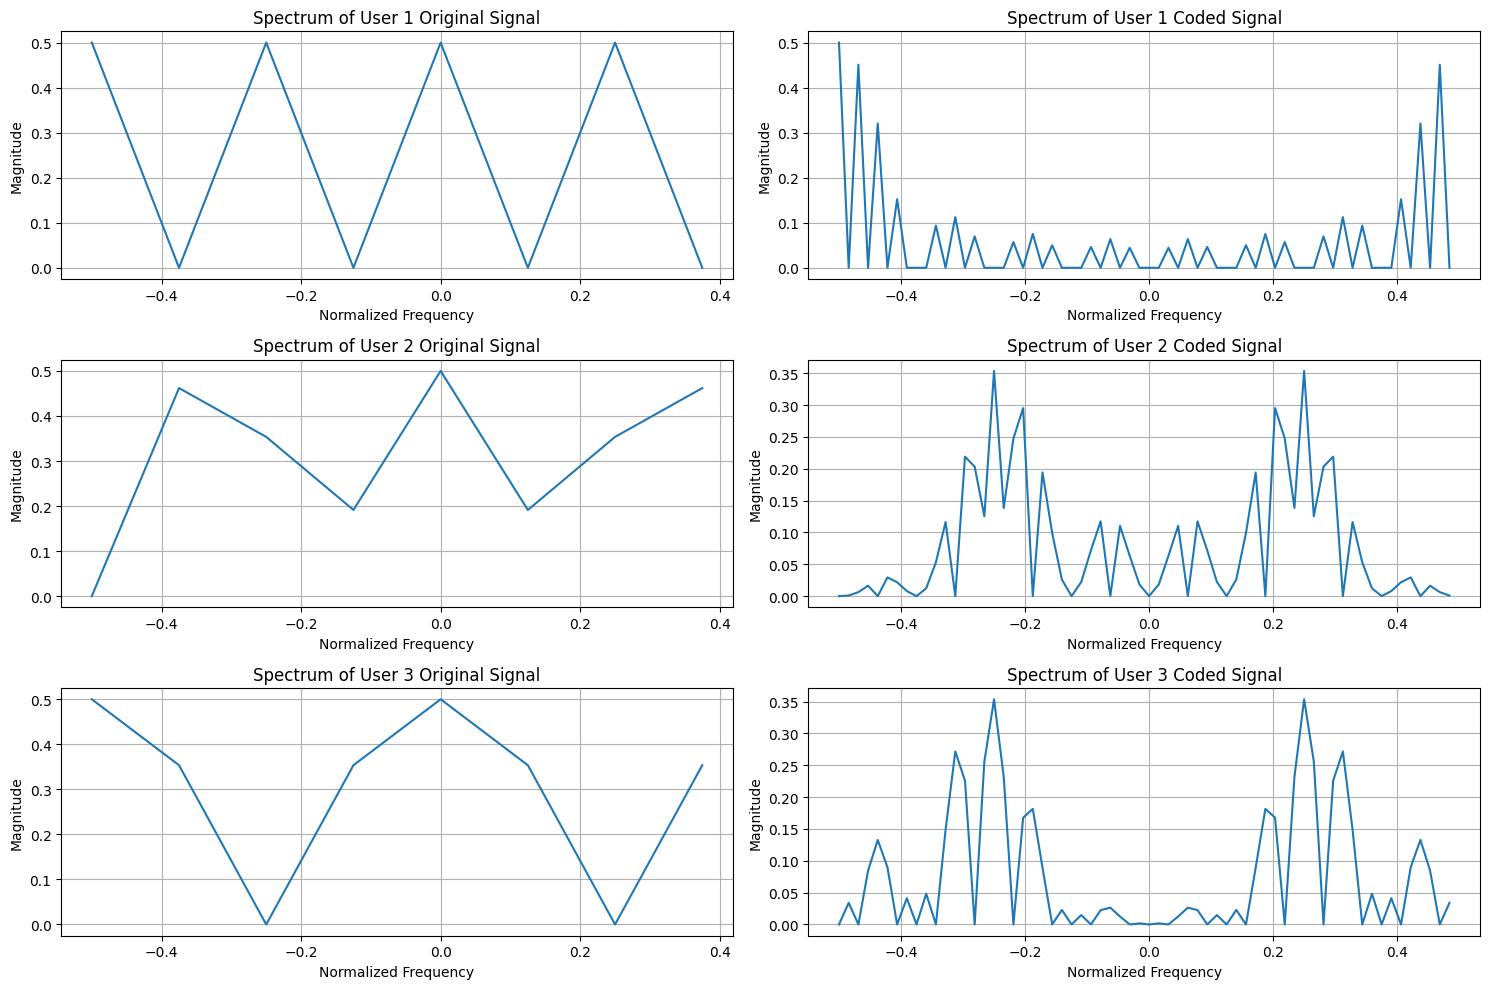

In [6]:
# 5. Show the spectrum of original and coded signals

def plot_spectrum(signal, title, subplot_pos):

    N = len(signal)

    # FFT
    yf = np.fft.fft(signal)

    # Shift spectrum to center zero frequency
    yf_shifted = np.fft.fftshift(yf)

    # Frequency axis
    xf = np.fft.fftfreq(N, d=1)
    xf_shifted = np.fft.fftshift(xf)

    # Magnitude spectrum
    magnitude = np.abs(yf_shifted) / N

    plt.subplot(subplot_pos)
    plt.plot(xf_shifted, magnitude)

    plt.title(title)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Magnitude')

    plt.grid(True)


plt.figure(figsize=(15, 10))

# User 1
plot_spectrum(m1,
              'Spectrum of User 1 Original Signal',
              321)

plot_spectrum(coded_signal_1,
              'Spectrum of User 1 Coded Signal',
              322)

# User 2
plot_spectrum(m2,
              'Spectrum of User 2 Original Signal',
              323)

plot_spectrum(coded_signal_2,
              'Spectrum of User 2 Coded Signal',
              324)

# User 3
plot_spectrum(m3,
              'Spectrum of User 3 Original Signal',
              325)

plot_spectrum(coded_signal_3,
              'Spectrum of User 3 Coded Signal',
              326)

plt.tight_layout()
plt.show()

In [ ]:
#comente o impacto da codificação no espectro do sinal.

### Análise do Impacto da Codificação no Espectro (Exercício 1A)

Observando os gráficos gerados, notamos que o sinal original de cada usuário possui um espectro concentrado em frequências mais baixas. Ao aplicar a codificação de Hadamard (espalhamento):

1.  **Alargamento Espectral:** A energia do sinal, que antes estava concentrada, agora é distribuída por uma faixa de frequência muito mais ampla. Isso é característico de sistemas de espectro espalhado (Spread Spectrum).
2.  **Redução da Densidade de Potência:** Como a mesma energia é espalhada por uma largura de banda maior, a amplitude do sinal no domínio da frequência diminui, tornando-o mais resiliente a interferências de banda estreita e mais difícil de ser detectado por receptores não autorizados.

In [ ]:
#B) Received Signal with AWGN

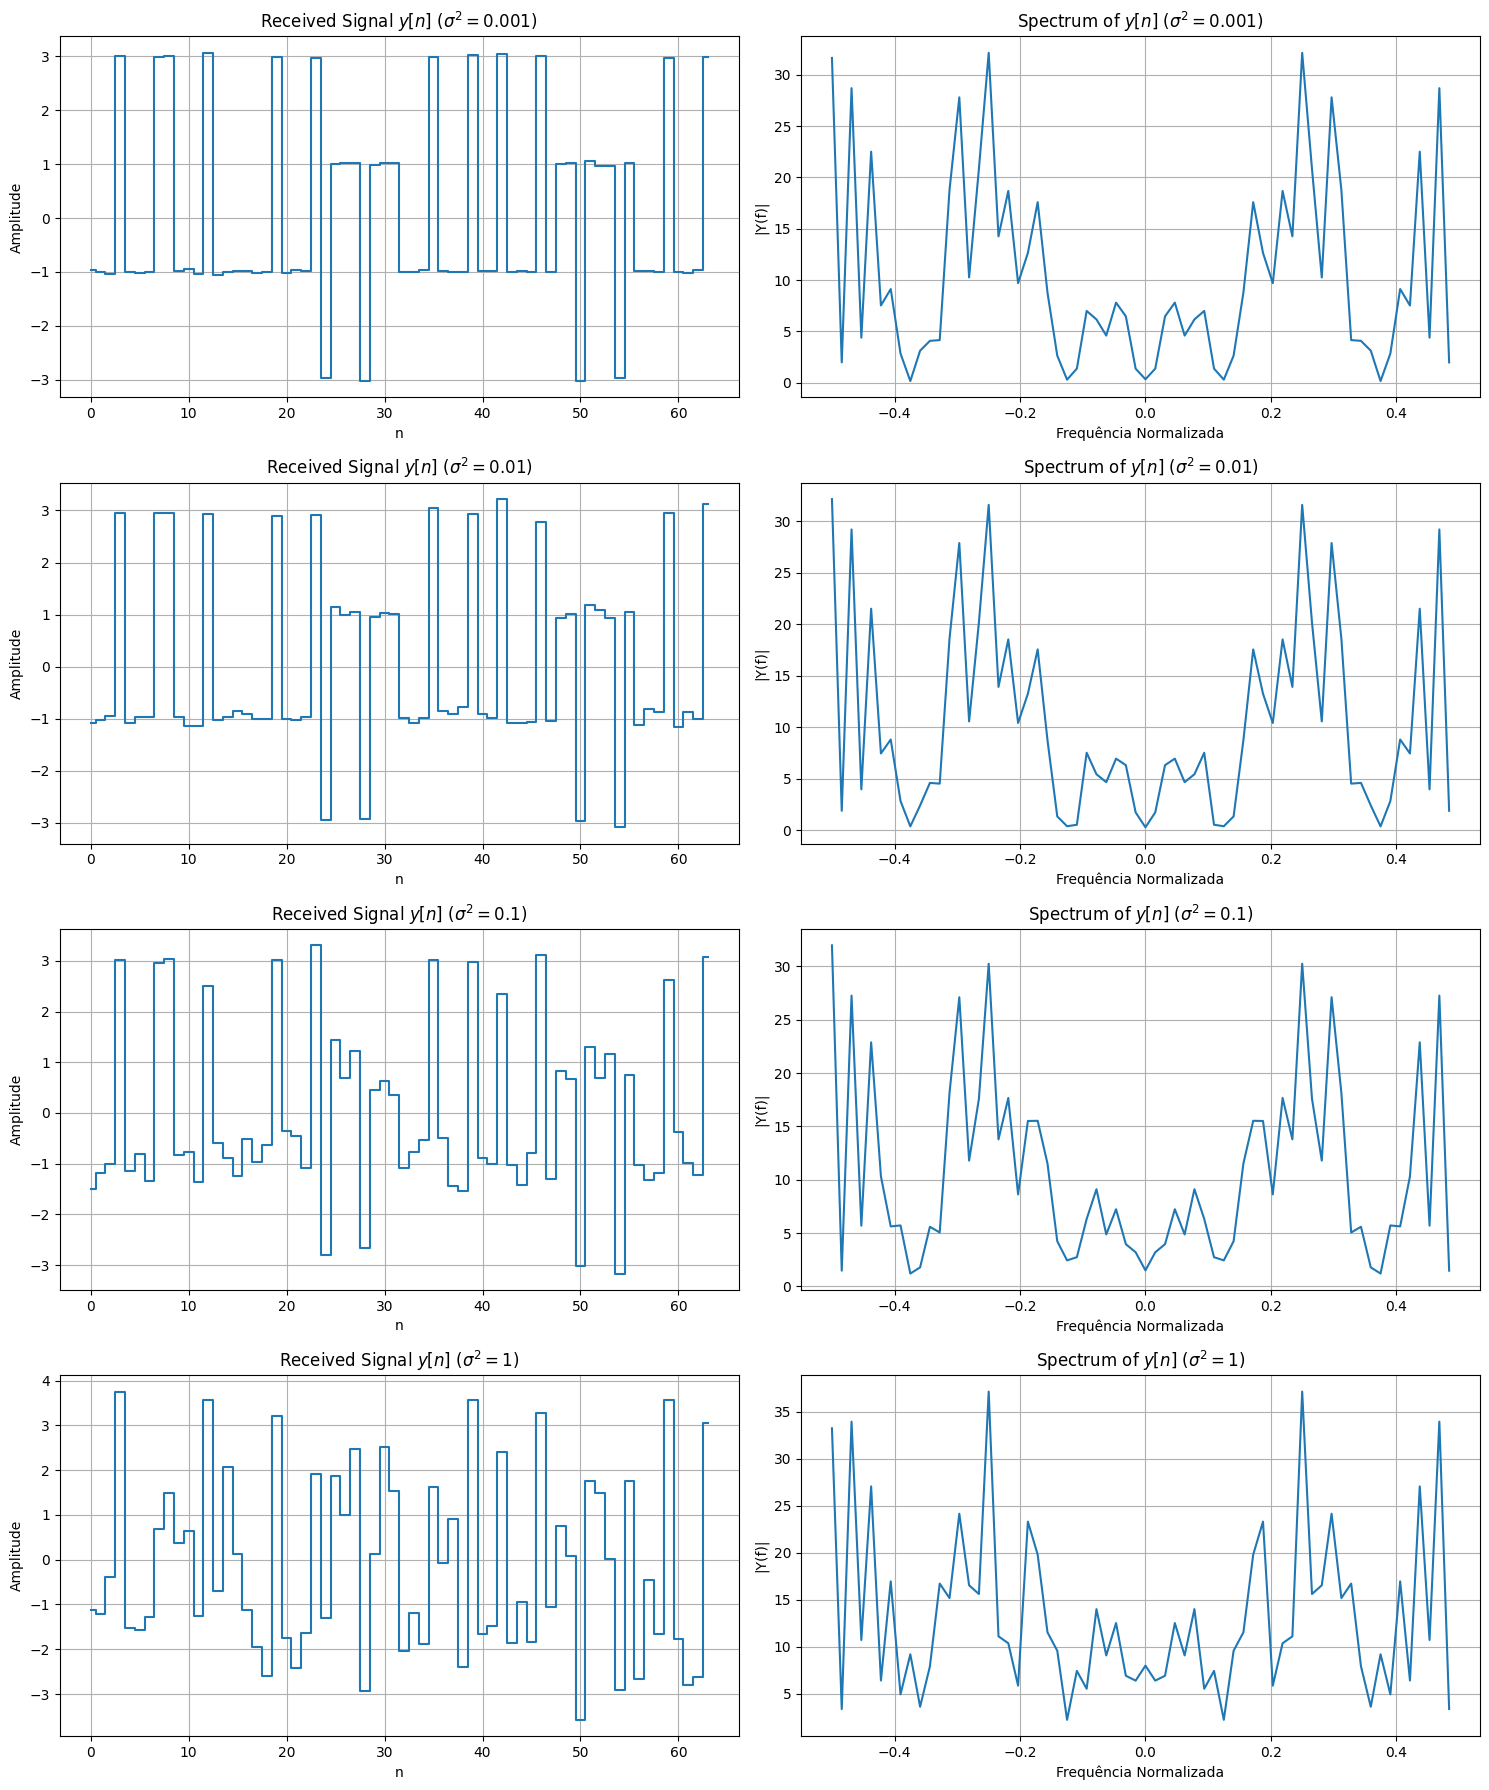

In [9]:
# ==========================================
# 6. Canal com ruído AWGN
# y[n] = x1[n] + x2[n] + x3[n] + w[n]
# ==========================================

# Soma dos sinais codificados
sum_coded_signals = (
    coded_signal_1 +
    coded_signal_2 +
    coded_signal_3
)

# Tamanho do sinal codificado
signal_length = len(sum_coded_signals)

# Variâncias do ruído
sigma2_values = [1e-3, 1e-2, 1e-1, 1]

# ==========================================
# Figura principal
# ==========================================

plt.figure(figsize=(15, 18))

for i, sigma2 in enumerate(sigma2_values):

    # Desvio padrão
    sigma = np.sqrt(sigma2)

    # ======================================
    # Ruído AWGN
    # ======================================

    w = np.random.normal(
        0,
        sigma,
        size=signal_length
    )

    # ======================================
    # Sinal recebido
    # ======================================

    y = sum_coded_signals + w

    # ======================================
    # Gráfico no tempo
    # ======================================

    plt.subplot(len(sigma2_values), 2, 2*i + 1)

    plt.step(
        range(signal_length),
        y,
        where='mid'
    )

    plt.title(
        rf'Received Signal $y[n]$ ($\sigma^2 = {sigma2}$)'
    )

    plt.xlabel('n')
    plt.ylabel('Amplitude')

    plt.grid(True)

    # ======================================
    # Espectro do sinal recebido
    # ======================================

    plot_spectrum(
        y,
        rf'Spectrum of $y[n]$ ($\sigma^2 = {sigma2}$)',
        len(sigma2_values)*100 + 20 + (2*i + 2)
    )

plt.tight_layout()
plt.show()

In [ ]:
#mostre o espectro de y[n] e comente o impacto de σ^2 nele.

### Impacto do Ruído AWGN no Sinal Recebido (Exercício 1B)

Ao variar a potência do ruído ($\sigma^2$):

1.  **Degradação no Tempo:** Para valores baixos como $10^{-3}$, a estrutura dos sinais individuais somados ainda é vagamente visível. Com $\sigma^2 = 1$, o sinal no domínio do tempo torna-se praticamente indistinguível de um ruído aleatório.
2.  **Piso de Ruído no Espectro:** No domínio da frequência, o aumento de $\sigma^2$ eleva o 'piso' do espectro. Isso mascara os componentes de frequência do sinal de informação. Em CDMA, a capacidade de recuperar o sinal original sob alto ruído dependerá do ganho de processamento (tamanho do código de Hadamard).

### (c) (c) Recuperando $m_k[n]$ de $y[n]$ e o impacto de $w[n]$ em $\hat{m}_k[n]$ (Derivação Matemática)


Vamos usar notação vetorial para mostrar como recuperar $m_k[n]$ do sinal recebido $y[n]$ e analisar o impacto do ruído $w[n]$.

Temos $N$ usuários, e para cada usuário $k$, um sinal original $m_k$ (um vetor de comprimento $L$) e um código de Hadamard ortogonal $c_k$ (um vetor de comprimento $L$). Em nosso caso específico, $N=3$ e $L=8$.

O sinal codificado para o usuário $k$ é dado por $x_k[n] = m_k[n] \cdot c_k[n]$. No entanto, este é um modelo simplificado. Em um sistema CDMA típico, cada bit de $m_k$ é espalhado por todo o código $c_k$. Se $m_k[j]$ é o $j$-ésimo bit dos dados do usuário $k$, então a sequência transmitida para esse bit é $m_k[j] \cdot c_k$. Para simplificar e manter a consistência com as partes anteriores do problema, manteremos a multiplicação elemento a elemento $x_k[n] = m_k[n] \cdot c_k[n]$, onde $m_k[n]$ representa uma sequência de símbolos de informação (ou bits).

O sinal recebido $y[n]$ é a soma de todos os sinais codificados mais o Ruído Gaussiano Branco Aditivo (AWGN) $w[n]$:

$$y[n] = \sum_{k=1}^{N} x_k[n] + w[n]$$

Substituindo $x_k[n] = m_k[n] \cdot c_k[n]$:

$$y[n] = \sum_{k=1}^{N} m_k[n] \cdot c_k[n] + w[n]$$

Na notação vetorial, onde $m_k$, $c_k$, $w$ e $y$ são vetores de comprimento $L$ (em nosso caso, $L=8$):

$$\mathbf{y} = \sum_{k=1}^{N} \mathbf{m}_k \odot \mathbf{c}_k + \mathbf{w}$$


onde $\odot$ denota o produto elemento a elemento (Hadamard).

Para recuperar o sinal de um usuário específico, digamos o usuário $j$, o receptor desespalha o sinal recebido $y$ usando o código $c_j$ do usuário $j$. Isso é tipicamente feito calculando o produto interno de $y$ com $c_j$, ou em um contexto de sequência, pela multiplicação elemento a elemento e depois somando, ou aplicando a transformada de Hadamard se toda a sequência for tratada como um bloco.

Vamos supor que estamos tentando estimar o sinal original $m_j$. A operação de desespalhamento envolve multiplicar o sinal recebido $y$ pelo código do usuário $c_j$ e, em seguida, somar (ou calcular a média) o resultado. Isso efetivamente correlaciona o sinal recebido com o código do usuário desejado.

O sinal estimado para o usuário $j$, denotado como $\hat{m}_j$, pode ser obtido por:

$$\hat{\mathbf{m}}_j = \frac{1}{L} \left( \mathbf{y} \odot \mathbf{c}_j \right)$$

Este é um produto elemento a elemento seguido de escalonamento. Vamos analisar um único elemento $n$ do sinal estimado $\hat{m}_j[n]$:

$$\hat{m}_j[n] = \frac{1}{L} \sum_{i=1}^{L} y[i] \cdot c_j[i]$$

Substituindo a expressão para $y[i]$:

$$\hat{m}_j[n] = \frac{1}{L} \sum_{i=1}^{L} \left( \sum_{k=1}^{N} m_k[i] \cdot c_k[i] + w[i] \right) \cdot c_j[i]$$

$$\hat{m}_j[n] = \frac{1}{L} \sum_{i=1}^{L} \left( \sum_{k=1}^{N} m_k[i] \cdot c_k[i] \cdot c_j[i] + w[i] \cdot c_j[i] \right)$$

Podemos separar as somas:

$$\hat{m}_j[n] = \frac{1}{L} \sum_{i=1}^{L} \sum_{k=1}^{N} m_k[i] \cdot c_k[i] \cdot c_j[i] + \frac{1}{L} \sum_{i=1}^{L} w[i] \cdot c_j[i]$$

Agora, vamos nos concentrar no primeiro termo. Podemos trocar a ordem do somatório:

$$\frac{1}{L} \sum_{k=1}^{N} \sum_{i=1}^{L} m_k[i] \cdot c_k[i] \cdot c_j[i]$$

Como os códigos de Hadamard são ortogonais, o seu produto interno é zero para códigos diferentes e $L$ para o mesmo código:

$$\sum_{i=1}^{L} c_k[i] \cdot c_j[i] = \begin{cases} L & \text{if } k=j \\ 0 & \text{if } k \neq j \end{cases}$$


Portanto, para $k=j$, o produto interno é $L$. Para $k \neq j$, é $0$. Em nosso modelo simplificado de multiplicação elemento a elemento, não estamos calculando um produto interno direto em toda a sequência. Em vez disso, vamos considerar a propriedade de ortogonalidade para $c_k[i] \cdot c_j[i]$. Quando $k \neq j$, a sequência $c_k[i] \cdot c_j[i]$ idealmente deve ter uma média igual a zero ao longo do comprimento $L$.

Vamos supor que os códigos sejam normalizados de tal forma que $\frac{1}{L} \sum_{i=1}^{L} c_k[i] c_j[i] = \delta_{kj}$, onde $\delta_{kj}$ é o delta de Kronecker (1 se $k=j$, 0 caso contrário). No contexto da multiplicação elemento a elemento, essa suposição simplifica a recuperação.

Vamos reconsiderar o produto $c_k[i] \cdot c_j[i]$. Uma vez que $c_k[i]$ e $c_j[i]$ são 1 ou -1, seu produto também é 1 ou -1. A ortogonalidade significa que, se multiplicarmos o sinal recebido por $c_j[n]$, os sinais de outros usuários $k \neq j$ serão eliminados (ou sua soma será zero), deixando apenas o sinal do usuário $j$ somado ao ruído residual.

### (d) Recovering $\hat{m}_k[n]$ from $y[n]$ and Error Probability

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

N = 8                 # comprimento do código Hadamard
num_users = 3         # número de usuários
num_bits = 10000      # quantidade de bits para estimar probabilidade de erro

# Variâncias do ruído
sigma2_values = np.logspace(-3, 1, 20)

# Matriz de Hadamard
H = hadamard(N)

# Seleciona 3 códigos ortogonais
c1 = H[1]
c2 = H[2]
c3 = H[3]

codes = [c1, c2, c3]

In [ ]:
# -----------------------------
# Geração das mensagens
# -----------------------------

m1 = np.random.choice([-1, 1], size=num_bits)
m2 = np.random.choice([-1, 1], size=num_bits)
m3 = np.random.choice([-1, 1], size=num_bits)

messages = [m1, m2, m3]

In [ ]:
# -----------------------------
# Função de codificação
# -----------------------------

def spread_signal(message, code):
    """
    Realiza o espalhamento do sinal:
    cada bit é multiplicado pelo código Hadamard.
    """
    return np.array([bit * code for bit in message])

In [ ]:
# Sinais codificados
x1 = spread_signal(m1, c1)
x2 = spread_signal(m2, c2)
x3 = spread_signal(m3, c3)

In [ ]:
# -----------------------------
# Recuperação do sinal
# -----------------------------

def recover_signal(y, code):
    """
    Recupera o sinal utilizando correlação
    com o código do usuário.
    """

    # Produto interno
    corr = np.dot(y, code)

    # Normalização
    corr = corr / len(code)

    # Decisão
    return np.where(corr >= 0, 1, -1)

In [ ]:
# -----------------------------
# Simulação da BER
# -----------------------------

ber_user1 = []

for sigma2 in sigma2_values:

    sigma = np.sqrt(sigma2)

    recovered_bits = []

    for i in range(num_bits):

        # Sinal recebido
        y = x1[i] + x2[i] + x3[i]

        # AWGN
        noise = np.random.normal(0, sigma, N)

        y = y + noise

        # Recuperação do usuário 1
        m_hat = recover_signal(y, c1)

        recovered_bits.append(m_hat)

    recovered_bits = np.array(recovered_bits)

    # Probabilidade de erro
    errors = np.sum(recovered_bits != m1)
    ber = errors / num_bits

    ber_user1.append(ber)

    print(f"sigma² = {sigma2:.4f} -> BER = {ber:.6f}")

sigma² = 0.0010 -> BER = 0.000000
sigma² = 0.0016 -> BER = 0.000000
sigma² = 0.0026 -> BER = 0.000000
sigma² = 0.0043 -> BER = 0.000000
sigma² = 0.0070 -> BER = 0.000000
sigma² = 0.0113 -> BER = 0.000000
sigma² = 0.0183 -> BER = 0.000000
sigma² = 0.0298 -> BER = 0.000000
sigma² = 0.0483 -> BER = 0.000000
sigma² = 0.0785 -> BER = 0.000000
sigma² = 0.1274 -> BER = 0.000000
sigma² = 0.2069 -> BER = 0.000000
sigma² = 0.3360 -> BER = 0.000000
sigma² = 0.5456 -> BER = 0.000000
sigma² = 0.8859 -> BER = 0.000900
sigma² = 1.4384 -> BER = 0.008700
sigma² = 2.3357 -> BER = 0.030400
sigma² = 3.7927 -> BER = 0.072600
sigma² = 6.1585 -> BER = 0.127700
sigma² = 10.0000 -> BER = 0.176600


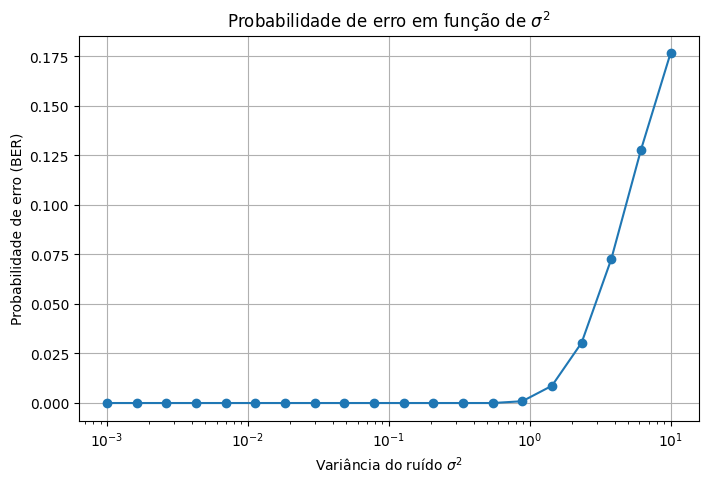

In [ ]:
# -----------------------------
# Gráfico BER x sigma²
# -----------------------------

plt.figure(figsize=(8,5))

plt.semilogx(sigma2_values, ber_user1, marker='o')

plt.xlabel(r'Variância do ruído $\sigma^2$')
plt.ylabel('Probabilidade de erro (BER)')
plt.title(r'Probabilidade de erro em função de $\sigma^2$')

plt.grid(True)

plt.show()

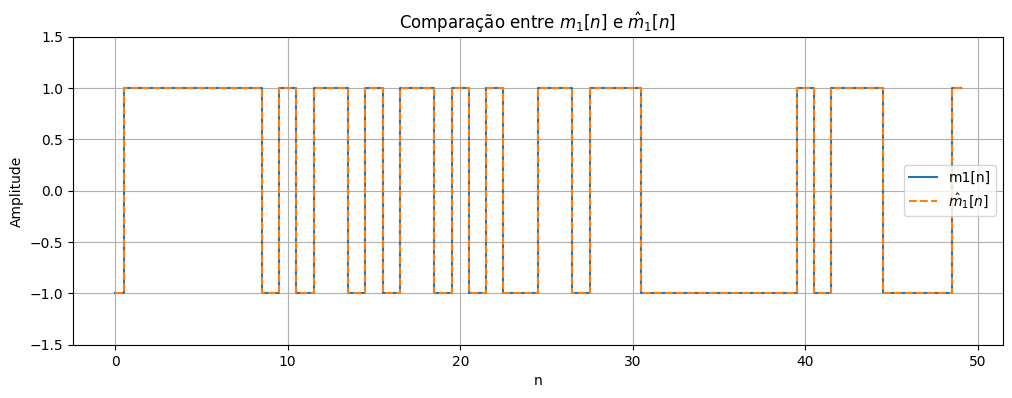

In [ ]:
# -----------------------------
# Comparação visual
# -----------------------------

sigma2 = 0.1
sigma = np.sqrt(sigma2)

estimated = []

for i in range(50):

    y = x1[i] + x2[i] + x3[i]

    noise = np.random.normal(0, sigma, N)

    y = y + noise

    m_hat = recover_signal(y, c1)

    estimated.append(m_hat)

estimated = np.array(estimated)

plt.figure(figsize=(12,4))

plt.step(range(50), m1[:50], where='mid', label='m1[n]')
plt.step(range(50), estimated, where='mid', linestyle='--', label=r'$\hat{m}_1[n]$')

plt.ylim([-1.5, 1.5])

plt.xlabel('n')
plt.ylabel('Amplitude')

plt.title(r'Comparação entre $m_1[n]$ e $\hat{m}_1[n]$')

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
#Observa-se que a probabilidade de erro aumenta conforme a variância do ruído σ^2 cresce. Para valores pequenos de ruído, o sistema CDMA consegue recuperar corretamente os sinais transmitidos devido à ortogonalidade dos códigos de Hadamard, resultando em uma taxa de erro próxima de zero.
#Entretanto, à medida que a potência do ruído AWGN aumenta, o processo de correlação utilizado na recuperação dos sinais passa a sofrer maior interferência. Isso reduz a confiabilidade da detecção dos bits transmitidos, aumentando a probabilidade de erro.
#O gráfico BER × σ^2 evidencia que o desempenho do sistema é fortemente dependente da relação sinal-ruído. Mesmo com a utilização de códigos ortogonais, ruídos de alta potência degradam significativamente a recuperação dos sinais no receptor.

In [ ]:
#E)

### (e) Impacto da Matriz de Código Distorcida no Receptor sobre $\hat{m}_k[n]$ (Derivação Matemática)

Consideremos o cenário em que o receptor não possui os códigos de Hadamard originais e perfeitamente ortogonais. Em vez disso, a matriz de código disponível no receptor, denotada como $\mathbf{\hat{C}} \in \mathbb{R}^{L \times L}$, é uma versão ruidosa da matriz de código verdadeira $\mathbf{C} \in \mathbb{R}^{L \times L}$.


$$\hat{\mathbf{C}} = \mathbf{C} + \mathbf{W}_{code}$$


onde $\mathbf{W}_{code} \sim \mathcal{N}(\mathbf{0}_{L \times L}, \sigma_c^2 \mathbf{I}_L)$ é uma matriz AWGN que causa distorção no código disponível no receptor. Aqui, $\sigma_c^2$ representa a variância do ruído que afeta cada elemento da matriz de código.

É nos dado que o ruído do canal $w[n]$ é zero, portanto o sinal recebido $y[n]$ é simplesmente a soma dos sinais codificados:


$$y[n] = \sum_{k=1}^{N} x_k[n]$$

Substituindo $x_k[n] = m_k[n] \cdot c_k[n]$:

$$y[n] = \sum_{k=1}^{N} m_k[n] \cdot c_k[n]$$

Em notação vetorial:

$$\mathbf{y} = \sum_{k=1}^{N} \mathbf{m}_k \odot \mathbf{c}_k$$

Para recuperar o sinal para o usuário $j$, o receptor desespalha o sinal recebido $\mathbf{y}$ usando seu código (distorcido) $\mathbf{\hat{c}}_j$, que é a $j$-ésima linha de $\mathbf{\hat{C}}$. O processo de recuperação elemento a elemento é:

$$\hat{m}_j[n] = \text{sign}(y[n] \cdot \hat{c}_j[n])$$

Substitua as expressões para $y[n]$ e $\hat{c}_j[n]$:

$$\hat{m}_j[n] = \text{sign}\left( \left( \sum_{k=1}^{N} m_k[n] \cdot c_k[n] \right) \cdot (c_j[n] + w_{code_j}[n]) \right)$$

onde $w_{code_j}[n]$ é o $n$-ésimo elemento da $j$-ésima linha de $\mathbf{W}_{code}$.

Expanda o produto:

$$\hat{m}_j[n] = \text{sign}\left( \left( m_j[n] c_j[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] \right) (c_j[n] + w_{code_j}[n]) \right)$$

$$\hat{m}_j[n] = \text{sign}\left( m_j[n] c_j^2[n] + m_j[n] c_j[n] w_{code_j}[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] c_j[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] w_{code_j}[n] \right)$$

Como $c_j[n]$ só pode ser 1 ou -1, $c_j^2[n] = 1$. Assim, a equação simplifica-se para:

$$\hat{m}_j[n] = \text{sign}\left( m_j[n] + m_j[n] c_j[n] w_{code_j}[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] c_j[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] w_{code_j}[n] \right)$$


Vamos analisar os termos dentro da função `sign `:

1. **Termo do Sinal Desejado**: $m_j[n]$ - Este é o sinal original para o usuário $j$, que queremos recuperar.

2. **Termo de Ruído devido ao Código Distorcido (Autointerferência)**: $m_j[n]c_j[n]w_{code_j}[n]$ - Este termo representa o ruído introduzido pela distorção no próprio código do usuário $j$. Como $m_j[n]$ e $c_j[n]$ são $\pm 1$, este termo possui as mesmas propriedades estatísticas que $w_{code_j}[n]$ (uma variável aleatória gaussiana com média zero e variância $\sigma_c^2$).

3. **Termo de Interferência Multiusuário (MUI)**: $\sum_{k \neq j}^N m_k[n]c_k[n]c_j[n]$ - Este termo representa a interferência de outros usuários. Em um sistema CDMA ideal com códigos perfeitamente ortogonais, se estivéssemos usando um receptor de correlação ao longo de toda a sequência, a soma deste termo idealmente seria zero. No entanto, com a multiplicação elemento a elemento, esta soma não é necessariamente zero para cada elemento $n$. Se $c_k[n]c_j[n]$ não for sempre zero para $k \neq j$, então os sinais de outros usuários irão interferir. A ortogonalidade dos códigos de Hadamard significa que a soma sobre toda a sequência $\sum_n c_k[n]c_j[n] = 0$ para $k \neq j$. Mas para um dado $n$, $c_k[n]c_j[n]$ é 1 ou -1, contribuindo assim para a interferência.


4. **Termo de Ruído devido ao Código Distorcido (Interferência Cruzada)**: $\sum_{k \neq j}^N m_k[n]c_k[n]w_{code_j}[n]$ - Este termo representa interferência adicional de outros usuários devido à distorção no código do usuário $j$. É o produto dos sinais dos outros usuários e do componente de ruído do código de desespalhamento do usuário $j$.

### Impacto da Distorção em $\hat{m}_k[n]$:

* **Perda de Ortogonalidade**: O impacto mais significativo de uma matriz de código distorcida $\mathbf{\hat{C}}$ é a perda da ortogonalidade perfeita. Quando o receptor usa $\mathbf{\hat{c}}_j$ para desespalhar, ele não filtra mais perfeitamente os sinais de outros usuários. Os termos $\sum_{k \neq j}^N m_k[n]c_k[n]c_j[n]$ e $\sum_{k \neq j}^N m_k[n]c_k[n]w_{code_j}[n]$ não se cancelarão, levando à Interferência Multiusuário (MUI).

* **Componente de Ruído Aditivo**: O termo $m_j[n]c_j[n]w_{code_j}[n]$ atua como um componente de ruído adicional que contamina diretamente o próprio sinal do usuário $j$. Isso reduz efetivamente a relação sinal-ruído (SNR) para o usuário pretendido, mesmo sem ruído de canal.

* **Erros de Decisão**: A presença desses termos de interferência e ruído significa que o argumento da função `sign` pode ser diferente do $m_j[n]$ verdadeiro. Se a soma desses termos de erro for grande o suficiente para inverter o sinal do $m_j[n]$ original, ocorrerá um erro de decisão, levando à recuperação incorreta do bit.

Em essência, a distorção na matriz de código do receptor introduz tanto autointerferência quanto interferência cruzada de outros usuários, degradando o desempenho do sistema CDMA ao aumentar o piso de ruído efetivo e levando a uma maior probabilidade de erro na recuperação dos sinais originais, mesmo na ausência de ruído de canal.

In [ ]:
#F)
N = 8
num_users = 3
num_bits = 10000

# Variâncias do ruído do código
sigma2_values = np.logspace(-4, 0, 20)

# Matriz de Hadamard
H = hadamard(N)

# Códigos dos usuários
c1 = H[1]
c2 = H[2]
c3 = H[3]

codes = [c1, c2, c3]

In [ ]:
# -----------------------------
# Mensagens binárias
# -----------------------------

m1 = np.random.choice([-1, 1], size=num_bits)
m2 = np.random.choice([-1, 1], size=num_bits)
m3 = np.random.choice([-1, 1], size=num_bits)

In [ ]:
# -----------------------------
# Espalhamento
# -----------------------------

def spread_signal(message, code):
    return np.array([bit * code for bit in message])

x1 = spread_signal(m1, c1)
x2 = spread_signal(m2, c2)
x3 = spread_signal(m3, c3)

In [ ]:
# -----------------------------
# Recuperação do sinal
# -----------------------------

def recover_signal(y, distorted_code):

    corr = np.dot(y, distorted_code)

    corr = corr / len(distorted_code)

    return 1 if corr >= 0 else -1

In [ ]:
# -----------------------------
# BER x sigma²
# -----------------------------

ber = []

for sigma2 in sigma2_values:

    sigma = np.sqrt(sigma2)

    estimated_bits = []

    for i in range(num_bits):

        # -----------------------------
        # Canal sem ruído:
        # y[n] = x1 + x2 + x3
        # -----------------------------

        y = x1[i] + x2[i] + x3[i]

        # -----------------------------
        # Distorção no código do receptor
        # -----------------------------

        W = np.random.normal(0, sigma, N)

        c1_distorted = c1 + W

        # Recuperação
        m_hat = recover_signal(y, c1_distorted)

        estimated_bits.append(m_hat)

    estimated_bits = np.array(estimated_bits)

    # Probabilidade de erro
    errors = np.sum(estimated_bits != m1)

    ber_value = errors / num_bits

    ber.append(ber_value)

    print(f"sigma² = {sigma2:.5f} -> BER = {ber_value:.6f}")

sigma² = 0.00010 -> BER = 0.000000
sigma² = 0.00016 -> BER = 0.000000
sigma² = 0.00026 -> BER = 0.000000
sigma² = 0.00043 -> BER = 0.000000
sigma² = 0.00070 -> BER = 0.000000
sigma² = 0.00113 -> BER = 0.000000
sigma² = 0.00183 -> BER = 0.000000
sigma² = 0.00298 -> BER = 0.000000
sigma² = 0.00483 -> BER = 0.000000
sigma² = 0.00785 -> BER = 0.000000
sigma² = 0.01274 -> BER = 0.000000
sigma² = 0.02069 -> BER = 0.000000
sigma² = 0.03360 -> BER = 0.000000
sigma² = 0.05456 -> BER = 0.000000
sigma² = 0.08859 -> BER = 0.000000
sigma² = 0.14384 -> BER = 0.000100
sigma² = 0.23357 -> BER = 0.000800
sigma² = 0.37927 -> BER = 0.003500
sigma² = 0.61585 -> BER = 0.017800
sigma² = 1.00000 -> BER = 0.049500


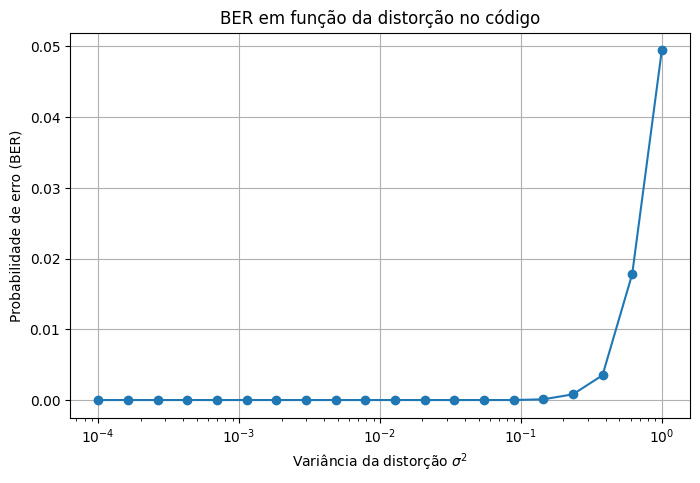

In [ ]:
# -----------------------------
# Gráfico
# -----------------------------

plt.figure(figsize=(8,5))

plt.semilogx(sigma2_values, ber, marker='o')

plt.xlabel(r'Variância da distorção $\sigma^2$')
plt.ylabel('Probabilidade de erro (BER)')

plt.title(r'BER em função da distorção no código')

plt.grid(True)

plt.show()

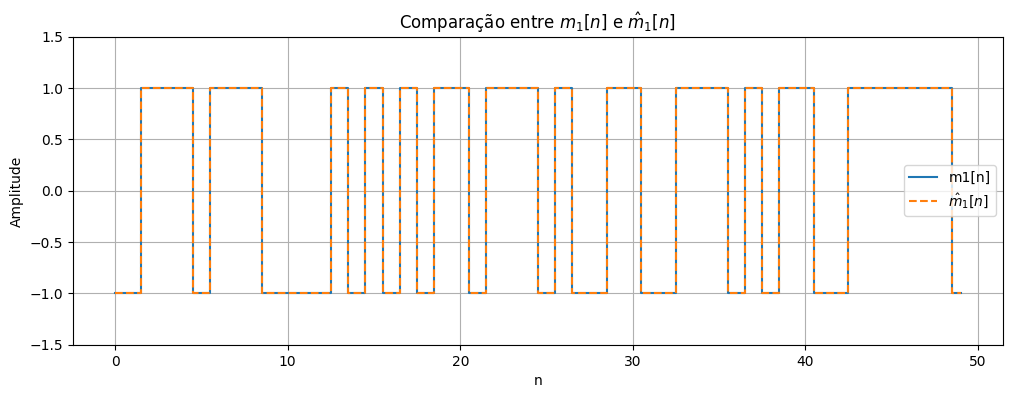

In [ ]:
# -----------------------------
# Comparação visual
# -----------------------------

sigma2 = 0.1
sigma = np.sqrt(sigma2)

estimated = []

for i in range(50):

    y = x1[i] + x2[i] + x3[i]

    W = np.random.normal(0, sigma, N)

    c1_distorted = c1 + W

    m_hat = recover_signal(y, c1_distorted)

    estimated.append(m_hat)

plt.figure(figsize=(12,4))

plt.step(range(50), m1[:50], where='mid', label='m1[n]')

plt.step(range(50), estimated,
         where='mid',
         linestyle='--',
         label=r'$\hat{m}_1[n]$')

plt.ylim([-1.5, 1.5])

plt.xlabel('n')
plt.ylabel('Amplitude')

plt.title(r'Comparação entre $m_1[n]$ e $\hat{m}_1[n]$')

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
#Observa-se que a probabilidade de erro aumenta conforme cresce a variância da distorção aplicada ao código disponível no receptor. Isso ocorre porque a perturbação introduzida em C reduz a ortogonalidade entre os códigos de Hadamard, prejudicando o processo de separação dos usuários.
#Mesmo na ausência de ruído no canal (w[n]=0), a utilização de códigos distorcidos provoca interferência entre usuários, fazendo com que o processo de correlação não recupere perfeitamente os símbolos transmitidos.
#Para valores pequenos de σ^2, os códigos ainda permanecem próximos dos originais e o sistema apresenta baixa taxa de erro. Entretanto, à medida que a distorção aumenta, a interferência entre usuários se torna mais significativa, elevando rapidamente a probabilidade de erro na detecção dos bits.

In [ ]:
#Exercício Prático 2

#Teorica

A análise clássica de Fourier é uma ferramenta fantástica, mas ela carrega um ponto cego clássico:
assume que as frequências de um sinal não mudam ao longo do tempo (sinais estacionários).
Quando você transforma um sinal puramente para o domínio da frequência usando Fourier, você descobre quais frequências existem, mas perde totalmente a noção de quando elas aconteceram.

Para contornar o Princípio da Incerteza de Heisenberg — que dita que não podemos ter resolução infinita tanto em tempo quanto em frequência simultaneamente —, surgiram as Transformadas de Wavelets.
Originadas da análise funcional, elas oferecem uma abordagem de multirresolução, adaptando dinamicamente o tamanho das janelas de análise.

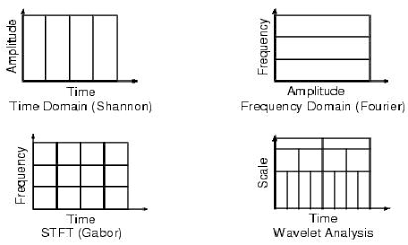


Como ilustrado acima, a diferença fundamental na forma como o espaço é mapeado fica evidente:

Fourier clássico: Dá resolução total de frequência, mas nenhuma de tempo.

STFT (Short-Time Fourier Transform): Tenta resolver o problema fatiando o sinal em janelas de tempo de tamanho fixo.
O problema é que a grade é rígida: se a janela for larga, a resolução de tempo é ruim; se for estreita, a resolução de frequência cai.

Análise de Wavelet: Usa janelas flexíveis. Frequências altas (mudanças rápidas e abruptas) ganham janelas de tempo estreitas, garantindo precisão temporal.
Frequências baixas (tendências lentas) ganham janelas de tempo largas, garantindo precisão de frequência.


O Princípio de FuncionamentoEm vez de decompor o sinal em ondas senoidais infinitas, a transformada de Wavelet usa uma wavelet-mãe ($\psi(t)$), que é essencialmente uma oscilação curta, com média zero e perfeitamente localizada no tempo.
Essa função sofre duas operações principais para varrer o sinal:Escalonamento ($a$): Dilata ou comprime a wavelet-mãe. Escalas pequenas comprimem a onda (focam em frequências altas); escalas grandes a dilatam (focam em frequências baixas).
Translação ($b$): Desloca a wavelet ao longo do eixo do tempo para mapear onde os eventos ocorrem.

A Transformada Contínua de Wavelet (CWT) é formalmente expressa por:

$$CWT(a, b) = \frac{1}{\sqrt{|a|}} \int_{-\infty}^{\infty} x(t) \psi^*\left(\frac{t-b}{a}\right) dt$$


Para aplicações computacionais e digitais, utiliza-se a Transformada Discreta de Wavelet (DWT), que restringe os valores de escala e translação a potências diádicas (potências de 2),
transformando a decomposição em bancos de filtros de passa-alta e passa-baixa altamente eficientes.



Principais Aplicações Práticas
Por sua capacidade única de capturar transientes (alterações repentinas no sinal), as wavelets revolucionaram diversas áreas:

Compressão de Imagens e Sinais: O padrão JPEG 2000 utiliza a DWT em vez da Transformada Discreta de Cosseno (DCT) usada no JPEG tradicional.
Isso elimina aqueles blocos pixelados em taxas de compressão agressivas, mantendo a suavidade e os detalhes das bordas.

Filtragem e Redução de Ruído (Denoising): Como os ruídos de alta frequência tendem a se espalhar por coeficientes específicos e isolados na transformada,
é possível aplicar um limiar (thresholding) para zerar o ruído sem borrar os transientes e bordas importantes do sinal original.

Engenharia Biomédica: Essencial na análise de exames como ECG (Eletrocardiograma) e EEG (Eletroencefalograma).
Eventos críticos como arritmias cardíacas ou picos de crises epiléticas são transientes localizados; as wavelets conseguem apontar com exatidão o milissegundo em que a anomalia começou.

Monitoramento de Sistemas e Detecção de Falhas: Na engenharia de controle e automação, falhas mecânicas em rolamentos de motores industriais ou curtos-circuitos intermitentes geram vibrações e transientes rápidos de corrente.
A análise por wavelets detecta essas "assinaturas de falha" muito antes de um alarme convencional disparar.

Geofísica e Processamento de Sinais Sísmicos: Utilizada para analisar abalos sísmicos e processar dados de reflexão acústica para mapear camadas do subsolo, auxiliando diretamente na exploração de petróleo e minerais.

In [ ]:
#Exercício Prático 3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 2000                                             # Signal length
t = np.arange(N + 1)                                 # Time values
x = np.zeros_like(t, dtype=np.float64)               # Initialize x as float to allow for sin wave additions

pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000]) # Initial position for each sinusoid function
T_sin = np.array([100, 40, 20, 10, 5])               # Sampling period of each sinusoid function

for i in range(5):
    m = pos_sin[i]
    n = pos_sin[i+1]

    segment_length = n - m
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n] = np.sin(2*np.pi*t_segment_values/T_sin[i])

amp_imp = np.array([3, -2, 2, 2.5, -2.5])
pos_imp = np.array([200, 372, 1324, 1343, 1802])
T_imp = np.array([5, 25, 5, 5, 5])

for i in range(5):
    m = pos_imp[i]
    relative_end_offset = int(T_imp[i] / 2)
    n = pos_imp[i] + relative_end_offset

    segment_length = n - m + 1
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n+1] += amp_imp[i] * (np.sin(2 *np.pi*t_segment_values/T_imp[i]))**2

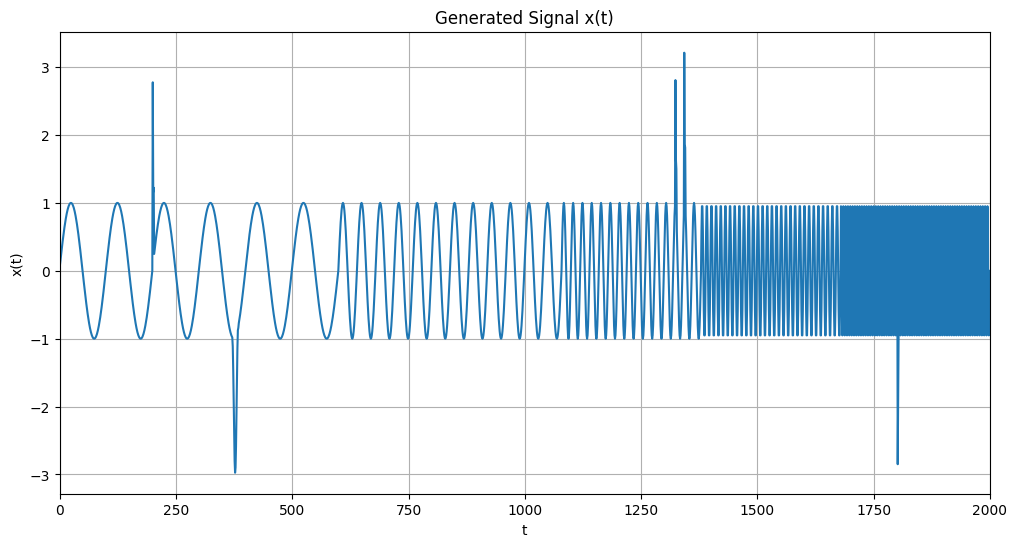

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(t, x)
plt.title('Generated Signal x(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.xlim(0, N)
plt.grid(True)
plt.show()

In [ ]:
#A) TEORICA

Com base na imagem fornecida, o gráfico apresenta um sinal no domínio do tempo, denotado como $x(t)$. Trata-se de um sinal não-estacionário, o que significa que o seu conteúdo de frequências se altera à medida que o tempo avança.

Uma análise visual detalhada revela que o sinal gerado é a composição de duas características principais:

1. Componente Senoidal com Frequência Variável (Sinal Base)A fundação do gráfico é uma forma de onda oscilatória (senoidal) que possui uma amplitude perfeitamente constante de 1 (variando entre -1 e 1 no eixo y). No entanto, a sua frequência aumenta em degraus ao longo do tempo $t$:

$t$ = 0 a 500: O sinal inicia com uma frequência baixa e constante.

$t$ = 500 a 1000: Ocorre um salto discreto, e a onda passa a oscilar de forma visivelmente mais rápida, mantendo essa nova frequência.

$t$ = 1000 a 2000: A frequência continua a aumentar em novos blocos ou estágios (visíveis aproximadamente em $t$ = 1000, $t$ = 1350 e $t$ = 1700), tornando as cristas das ondas cada vez mais espremidas e densas visualmente.

2. Ruído Impulsivo (Anomalias/Spikes)Sobrepostos ao comportamento senoidal regular, existem picos abruptos e de curtíssima duração. No contexto de processamento de sinais, isso representa ruído impulsivo ou perturbações transientes severas. Eles se destacam claramente por romperem a amplitude limite do sinal base:

Um pico positivo em $t \approx 200$ alcançando uma amplitude próxima a 2.8.

Um pico negativo agudo em $t \approx 380$ atingindo exatamente -3.0.

Uma dupla de picos positivos bastante próximos ao redor de $t \approx 1320$ e $t \approx 1350$, com amplitudes em torno de 2.8 e 3.2, respectivamente.

Um pico negativo profundo perto de $t \approx 1800$ com amplitude de aproximadamente -2.8.


## Conclusão Analítica
O script non_stationary_signal.ipynb foi projetado para sintetizar um cenário de teste comum na engenharia. A combinação das frequências que variam no tempo torna esse sinal excelente para testar análises de tempo-frequência (como espectrogramas gerados via STFT ou Transformadas Wavelet), uma vez que a Transformada de Fourier tradicional falharia em mostrar quando cada frequência ocorre. Paralelamente, os picos agudos inseridos propositalmente servem para validar a eficácia de técnicas de filtragem (como filtros de mediana) destinadas a limpar ruídos impulsivos sem destruir a estrutura e as transições do sinal original.

In [ ]:
#B)

In [ ]:
!pip install PyWavelets

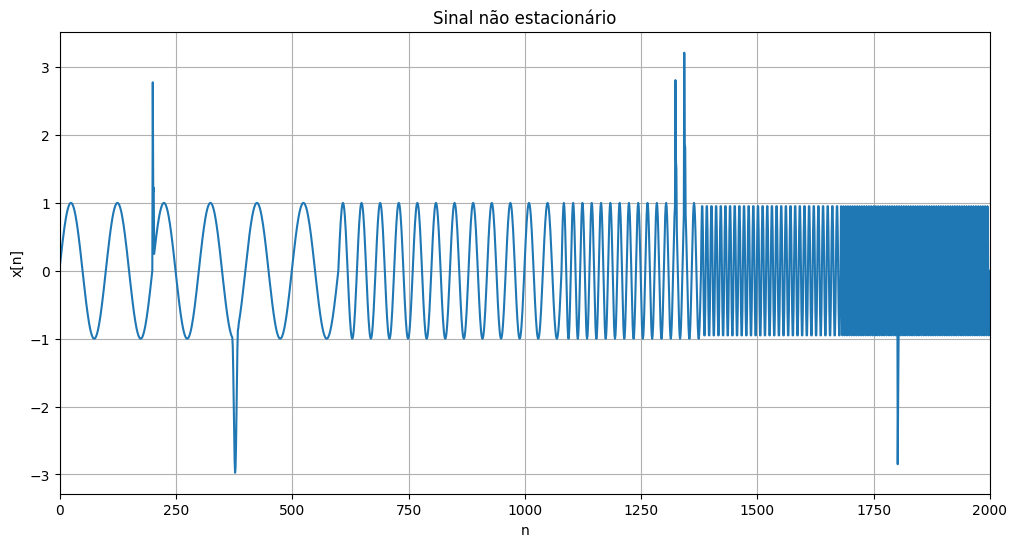

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pywt
# -----------------------------
# Geração do sinal
# -----------------------------

N = 2000

t = np.arange(N + 1)

x = np.zeros_like(t, dtype=np.float64)

# Componentes senoidais
pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000])

T_sin = np.array([100, 40, 20, 10, 5])

for i in range(5):

    m = pos_sin[i]
    n = pos_sin[i+1]

    segment_length = n - m

    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n] = np.sin(
        2*np.pi*t_segment_values/T_sin[i]
    )

# Componentes impulsivas
amp_imp = np.array([3, -2, 2, 2.5, -2.5])

pos_imp = np.array([200, 372, 1324, 1343, 1802])

T_imp = np.array([5, 25, 5, 5, 5])

for i in range(5):

    m = pos_imp[i]

    relative_end_offset = int(T_imp[i] / 2)

    n = pos_imp[i] + relative_end_offset

    segment_length = n - m + 1

    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n+1] += amp_imp[i] * (
        np.sin(
            2*np.pi*t_segment_values/T_imp[i]
        )
    )**2

# Visualização do sinal
plt.figure(figsize=(12,6))

plt.plot(t, x)

plt.title('Sinal não estacionário')

plt.xlabel('n')

plt.ylabel('x[n]')

plt.xlim(0, N)

plt.grid(True)

plt.show()

In [ ]:
# -----------------------------
# Conversão para PyTorch
# -----------------------------

signal_torch = torch.tensor(
    x,
    dtype=torch.float32
)

signal_torch = signal_torch.view(1,1,-1)

In [ ]:
# -----------------------------
# Wavelet utilizada
# -----------------------------

wavelet = pywt.Wavelet('bior4.4')

print(wavelet)

Wavelet bior4.4
  Family name:    Biorthogonal
  Short name:     bior
  Filters length: 10
  Orthogonal:     False
  Biorthogonal:   True
  Symmetry:       symmetric
  DWT:            True
  CWT:            False


In [ ]:
# -----------------------------
# Filtros de análise e síntese
# -----------------------------

dec_lo = wavelet.dec_lo
dec_hi = wavelet.dec_hi

rec_lo = wavelet.rec_lo
rec_hi = wavelet.rec_hi

print('===================================')
print('Filtro passa-baixa de análise')
print('===================================')

print(np.array(dec_lo))

print('\n===================================')
print('Filtro passa-alta de análise')
print('===================================')

print(np.array(dec_hi))

print('\n===================================')
print('Filtro passa-baixa de síntese')
print('===================================')

print(np.array(rec_lo))

print('\n===================================')
print('Filtro passa-alta de síntese')
print('===================================')

print(np.array(rec_hi))

Filtro passa-baixa de análise
[ 0.          0.03782846 -0.02384947 -0.1106244   0.37740286  0.85269868
  0.37740286 -0.1106244  -0.02384947  0.03782846]

Filtro passa-alta de análise
[-0.         -0.06453888  0.04068942  0.41809227 -0.78848562  0.41809227
  0.04068942 -0.06453888 -0.          0.        ]

Filtro passa-baixa de síntese
[ 0.         -0.06453888 -0.04068942  0.41809227  0.78848562  0.41809227
 -0.04068942 -0.06453888  0.          0.        ]

Filtro passa-alta de síntese
[ 0.         -0.03782846 -0.02384947  0.1106244   0.37740286 -0.85269868
  0.37740286  0.1106244  -0.02384947 -0.03782846]


In [ ]:
# -----------------------------
# Conversão dos filtros
# -----------------------------

low_filter = torch.tensor(
    dec_lo,
    dtype=torch.float32
).view(1,1,-1)

high_filter = torch.tensor(
    dec_hi,
    dtype=torch.float32
).view(1,1,-1)

In [ ]:
# -----------------------------
# Decomposição Wavelet
# -----------------------------

approx = torch.nn.functional.conv1d(
    signal_torch,
    low_filter,
    stride=2,
    padding=len(dec_lo)//2
)

detail = torch.nn.functional.conv1d(
    signal_torch,
    high_filter,
    stride=2,
    padding=len(dec_hi)//2
)

# Conversão para numpy
approx = approx.squeeze().detach().numpy()

detail = detail.squeeze().detach().numpy()

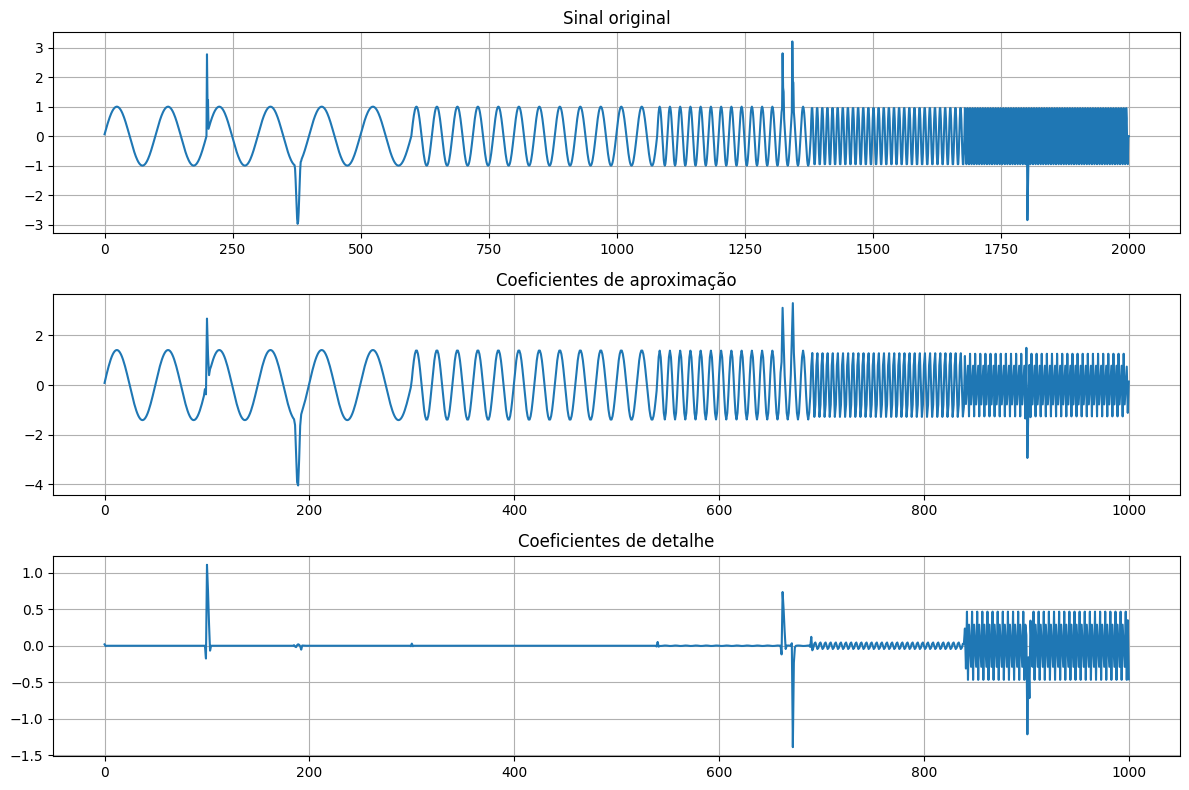

In [ ]:
# -----------------------------
# Resultados
# -----------------------------

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)

plt.plot(x)

plt.title('Sinal original')

plt.grid(True)

plt.subplot(3,1,2)

plt.plot(approx)

plt.title('Coeficientes de aproximação')

plt.grid(True)

plt.subplot(3,1,3)

plt.plot(detail)

plt.title('Coeficientes de detalhe')

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
#C)
# -----------------------------
# Decomposição em 5 níveis
# -----------------------------

coeffs = pywt.wavedec(
    x,
    wavelet='bior4.4',
    level=5
)

# Coeficientes
cA5 = coeffs[0]

cD5 = coeffs[1]
cD4 = coeffs[2]
cD3 = coeffs[3]
cD2 = coeffs[4]
cD1 = coeffs[5]

In [ ]:
# -----------------------------
# Coeficientes
# -----------------------------

print("===================================")
print("Coeficientes de aproximação cA5")
print("===================================")

print(cA5)

print("\n===================================")
print("Coeficientes de detalhe")
print("===================================")

print("\ncD5:\n", cD5)

print("\ncD4:\n", cD4)

print("\ncD3:\n", cD3)

print("\ncD2:\n", cD2)

print("\ncD1:\n", cD1)

Coeficientes de aproximação cA5
[ 8.00233110e-01  1.13180530e+00  1.01772490e+00  9.49320713e-01
  2.33941145e+00  3.82229212e+00 -4.74169563e+00  3.21519192e-01
  4.51049354e+00 -4.26388157e+00 -5.06822951e-02  4.95149557e+00
 -3.22501671e+00 -2.16321583e+00  5.08429920e+00 -2.81203837e+00
 -4.94598714e+00  5.10300495e+00 -9.89659438e-01 -4.12979309e+00
  4.47388814e+00  3.22046332e-01 -4.47457672e+00  1.16805647e+00
  1.32192882e-01 -1.62067182e-01 -3.36902116e-01 -5.33639391e-02
  3.03945923e-01  2.41212851e-01 -1.54868183e-01 -3.36926652e-01
 -5.33639391e-02  3.03945923e-01  2.41211609e-01 -1.60976229e-01
 -4.65206732e-01  2.83628268e-01 -6.73650763e-01  3.29449713e-01
 -2.64346548e-01  9.94782263e-02  9.90817180e-02 -2.45867043e-01
  2.94066404e-01  1.85816679e-01  1.11074591e+00 -5.86070406e-01
  1.70256224e-01 -2.99884796e-02 -2.08271999e-02 -1.33296688e-02
  1.33296688e-02  2.15947620e-02 -4.48910466e-03 -8.57442859e-03
 -1.23688465e-01 -1.85320938e-02 -3.79174031e-02  9.017022

In [ ]:
# -----------------------------
# Eixos temporais normalizados
# -----------------------------

t_original = np.linspace(0, 1, len(x))

t_cA5 = np.linspace(0, 1, len(cA5))

t_cD5 = np.linspace(0, 1, len(cD5))

t_cD4 = np.linspace(0, 1, len(cD4))

t_cD3 = np.linspace(0, 1, len(cD3))

t_cD2 = np.linspace(0, 1, len(cD2))

t_cD1 = np.linspace(0, 1, len(cD1))

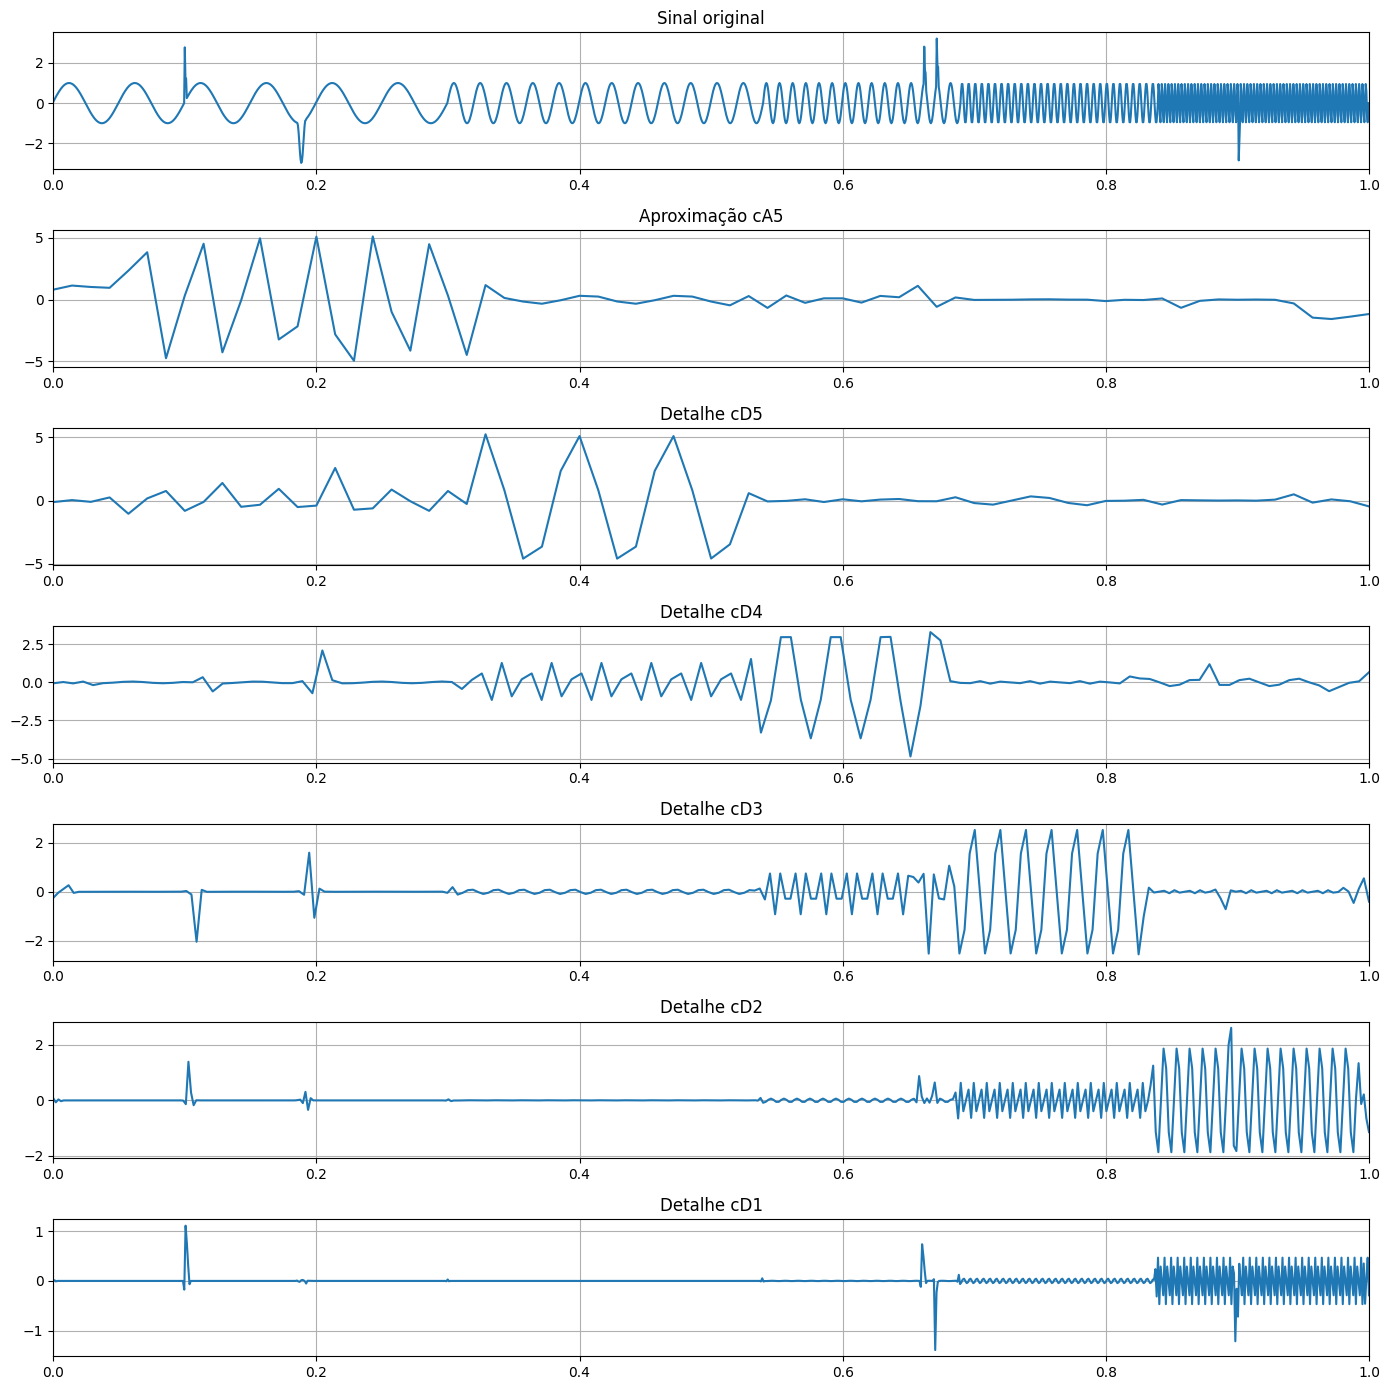

In [ ]:
# -----------------------------
# Subfaixas Wavelet
# -----------------------------

plt.figure(figsize=(14,14))

# Sinal original
plt.subplot(7,1,1)

plt.plot(t_original, x)

plt.title('Sinal original')

plt.xlim(0,1)

plt.grid(True)

# Aproximação
plt.subplot(7,1,2)

plt.plot(t_cA5, cA5)

plt.title('Aproximação cA5')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D5
plt.subplot(7,1,3)

plt.plot(t_cD5, cD5)

plt.title('Detalhe cD5')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D4
plt.subplot(7,1,4)

plt.plot(t_cD4, cD4)

plt.title('Detalhe cD4')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D3
plt.subplot(7,1,5)

plt.plot(t_cD3, cD3)

plt.title('Detalhe cD3')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D2
plt.subplot(7,1,6)

plt.plot(t_cD2, cD2)

plt.title('Detalhe cD2')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D1
plt.subplot(7,1,7)

plt.plot(t_cD1, cD1)

plt.title('Detalhe cD1')

plt.xlim(0,1)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
#A transformada wavelet em cinco estágios permitiu decompor o sinal em diferentes subfaixas de frequência, separando componentes de baixa e alta frequência em múltiplas escalas.
#Os coeficientes de aproximação cA5 representam as componentes de baixa frequência do sinal, preservando o comportamento global e as tendências mais lentas das componentes senoidais. Já os coeficientes de detalhe cD1 até cD5 representam componentes de frequência progressivamente menores.Observa-se que os detalhes de níveis baixos, principalmente cD1 e cD2, destacam os impulsos e variações rápidas do sinal, enquanto os níveis mais altos apresentam componentes mais suaves e associadas às mudanças lentas de frequência.
#A normalização do eixo temporal permitiu comparar diretamente as diferentes subfaixas ao longo do tempo, mesmo após os processos de dizimação realizados em cada estágio da decomposição wavelet. Isso facilita a visualização da localização temporal das componentes presentes no sinal não estacionário.

In [ ]:
#Exercício Prático 4

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving leleccum.mat to leleccum.mat


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
# -----------------------------
# Carregamento do sinal
# -----------------------------

data = loadmat('leleccum.mat')

# Nome da variável dentro do arquivo
signal = data['leleccum']

# Remove dimensões extras
signal = signal.squeeze()

print("Tamanho do sinal:", len(signal))

Tamanho do sinal: 4320


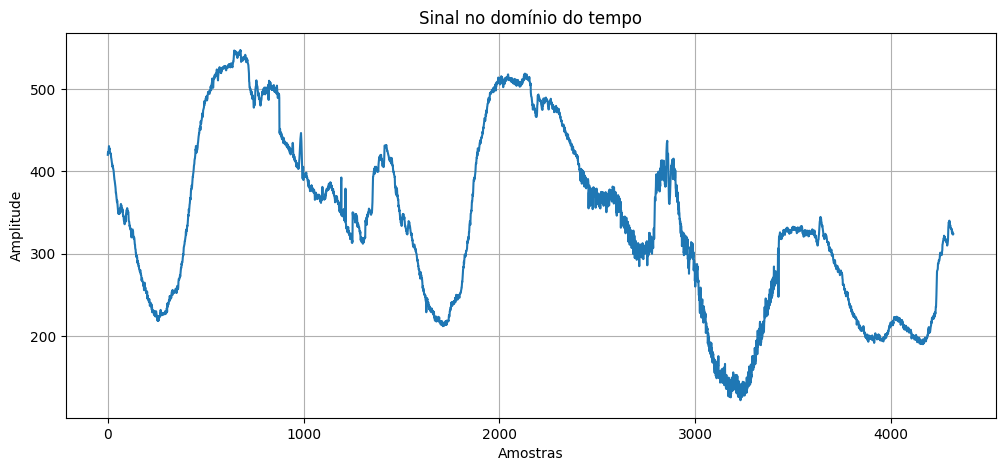

In [ ]:
# -----------------------------
# Sinal no tempo
# -----------------------------

n = np.arange(len(signal))

plt.figure(figsize=(12,5))

plt.plot(n, signal)

plt.title('Sinal no domínio do tempo')

plt.xlabel('Amostras')

plt.ylabel('Amplitude')

plt.grid(True)

plt.show()

In [ ]:
# -----------------------------
# FFT do sinal
# -----------------------------

N = len(signal)

X = np.fft.fft(signal)

# Magnitude normalizada
X_mag = np.abs(X)/N

# Frequências normalizadas
freq = np.fft.fftfreq(N)

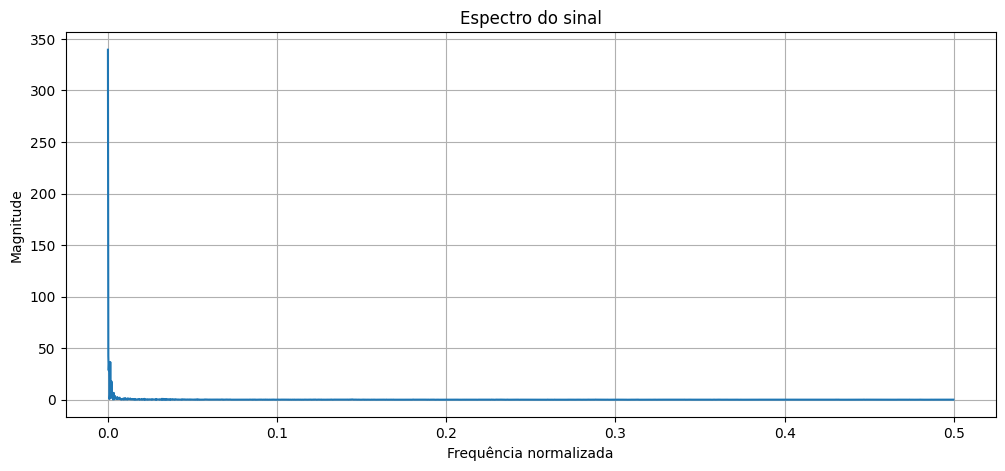

In [ ]:
# -----------------------------
# Espectro do sinal
# -----------------------------

plt.figure(figsize=(12,5))

plt.plot(freq[:N//2], X_mag[:N//2])

plt.title('Espectro do sinal')

plt.xlabel('Frequência normalizada')

plt.ylabel('Magnitude')

plt.grid(True)

plt.show()

In [ ]:
#Comente os resultados obtidos

### Análise do Sinal 'leleccum' no Tempo e Frequência (Exercício 4A)

1.  **Domínio do Tempo:** O sinal `leleccum` apresenta características de um sinal transiente com componentes oscilatórias, assemelhando-se a sinais de monitoramento de rede elétrica ou vibrações mecânicas. Note que a amplitude não é uniforme, indicando não-estacionariedade.
2.  **Espectro (FFT):** O espectro revela que a maior parte da energia do sinal está concentrada em baixas frequências (abaixo de 0.1 na escala normalizada). No entanto, a presença de componentes em frequências mais altas sugere detalhes rápidos ou ruídos sobrepostos ao sinal principal.

In [ ]:
#B)
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.io import loadmat
# -----------------------------
# Carregamento do arquivo
# -----------------------------

data = loadmat('leleccum.mat')

# Mostra variáveis disponíveis
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'leleccum'])


In [ ]:
signal = data['leleccum'].squeeze()

print("Tamanho do sinal:", len(signal))

Tamanho do sinal: 4320


In [ ]:
# -----------------------------
# Wavelet db4
# -----------------------------

wavelet = pywt.Wavelet('db4')

print(wavelet)

Wavelet db4
  Family name:    Daubechies
  Short name:     db
  Filters length: 8
  Orthogonal:     True
  Biorthogonal:   True
  Symmetry:       asymmetric
  DWT:            True
  CWT:            False


In [ ]:
# -----------------------------
# Filtros de análise e síntese
# -----------------------------

dec_lo = wavelet.dec_lo
dec_hi = wavelet.dec_hi

rec_lo = wavelet.rec_lo
rec_hi = wavelet.rec_hi

print('===================================')
print('Filtro passa-baixa de análise')
print('===================================')

print(np.array(dec_lo))

print('\n===================================')
print('Filtro passa-alta de análise')
print('===================================')

print(np.array(dec_hi))

print('\n===================================')
print('Filtro passa-baixa de síntese')
print('===================================')

print(np.array(rec_lo))

print('\n===================================')
print('Filtro passa-alta de síntese')
print('===================================')

print(np.array(rec_hi))

Filtro passa-baixa de análise
[-0.0105974   0.03288301  0.03084138 -0.18703481 -0.02798377  0.63088077
  0.71484657  0.23037781]

Filtro passa-alta de análise
[-0.23037781  0.71484657 -0.63088077 -0.02798377  0.18703481  0.03084138
 -0.03288301 -0.0105974 ]

Filtro passa-baixa de síntese
[ 0.23037781  0.71484657  0.63088077 -0.02798377 -0.18703481  0.03084138
  0.03288301 -0.0105974 ]

Filtro passa-alta de síntese
[-0.0105974  -0.03288301  0.03084138  0.18703481 -0.02798377 -0.63088077
  0.71484657 -0.23037781]


In [ ]:
# -----------------------------
# Decomposição wavelet
# -----------------------------

cA, cD = pywt.dwt(signal, 'db4')

print("Tamanho da aproximação:", len(cA))
print("Tamanho do detalhe:", len(cD))

Tamanho da aproximação: 2163
Tamanho do detalhe: 2163


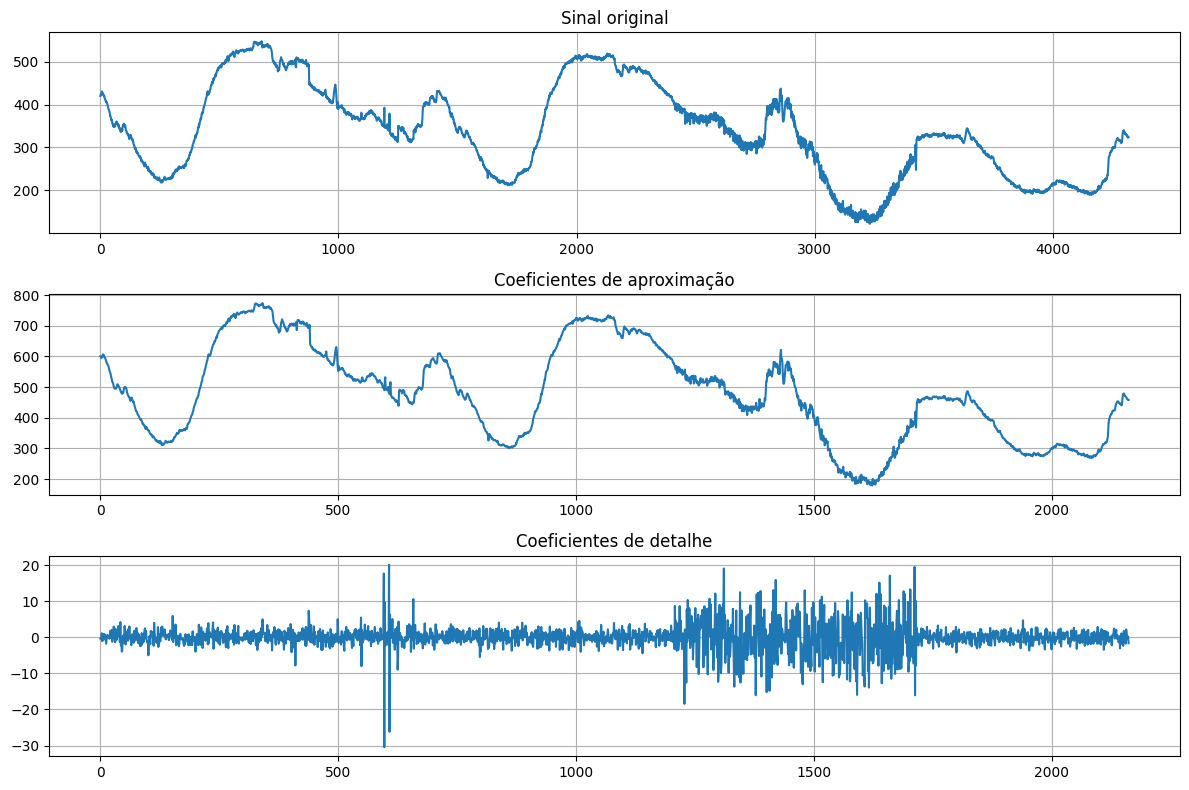

In [ ]:
# -----------------------------
# Resultados
# -----------------------------

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)

plt.plot(signal)

plt.title('Sinal original')

plt.grid(True)

plt.subplot(3,1,2)

plt.plot(cA)

plt.title('Coeficientes de aproximação')

plt.grid(True)

plt.subplot(3,1,3)

plt.plot(cD)

plt.title('Coeficientes de detalhe')

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
#C)
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.io import loadmat

# ============================================================
# Carregando o sinal do arquivo .mat
# ============================================================

data = loadmat('leleccum.mat')

# Mostra as variáveis disponíveis no arquivo
print(data.keys())

# ============================================================
# Pegando o sinal
# ============================================================

# Exemplo:
sinal = data['leleccum'].squeeze()

print("Tamanho do sinal:", len(sinal))

dict_keys(['__header__', '__version__', '__globals__', 'leleccum'])
Tamanho do sinal: 4320


In [ ]:
# ============================================================
# Transformada Wavelet - 5 níveis
# Wavelet: Daubechies 4 (db4)
# ============================================================

wavelet = 'db4'
nivel = 5

coef = pywt.wavedec(sinal, wavelet, level=nivel)

# coef[0] = aproximação final
# coef[1:] = detalhes do nível 5 ao 1

print("Número de conjuntos de coeficientes:", len(coef))

Número de conjuntos de coeficientes: 6


In [ ]:
# ============================================================
# Separando coeficientes
# ============================================================

aproximacao = coef[0]

detalhes = coef[1:]

for i, d in enumerate(detalhes):
    print(f"Detalhe nível {nivel - i}: tamanho = {len(d)}")

print("Aproximação final:", len(aproximacao))

Detalhe nível 5: tamanho = 141
Detalhe nível 4: tamanho = 276
Detalhe nível 3: tamanho = 546
Detalhe nível 2: tamanho = 1085
Detalhe nível 1: tamanho = 2163
Aproximação final: 141


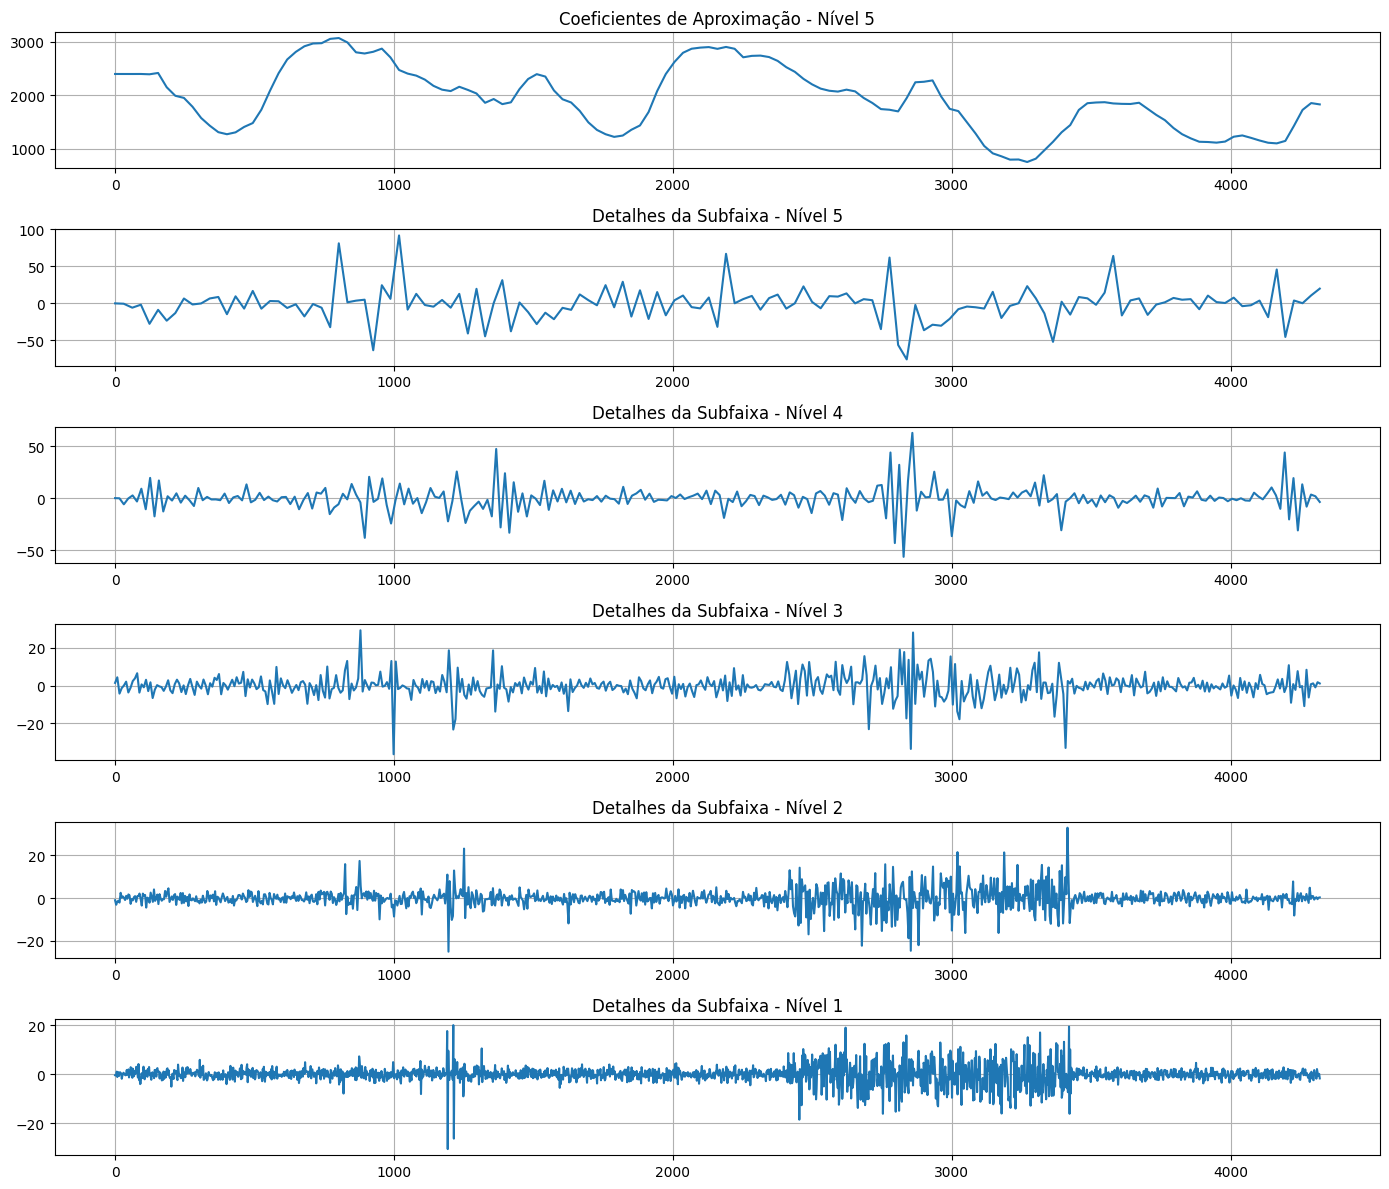

In [ ]:
# ============================================================
# Plotando aproximações e detalhes
# ============================================================

fig, axs = plt.subplots(nivel + 1, 1, figsize=(14, 12))

# Aproximação final
xA = np.linspace(0, len(sinal), len(aproximacao))

axs[0].plot(xA, aproximacao)
axs[0].set_title('Coeficientes de Aproximação - Nível 5')
axs[0].grid()

# Detalhes
for i, detalhe in enumerate(detalhes):

    nivel_atual = nivel - i

    xD = np.linspace(0, len(sinal), len(detalhe))

    axs[i + 1].plot(xD, detalhe)

    axs[i + 1].set_title(f'Detalhes da Subfaixa - Nível {nivel_atual}')
    axs[i + 1].grid()

plt.tight_layout()
plt.show()

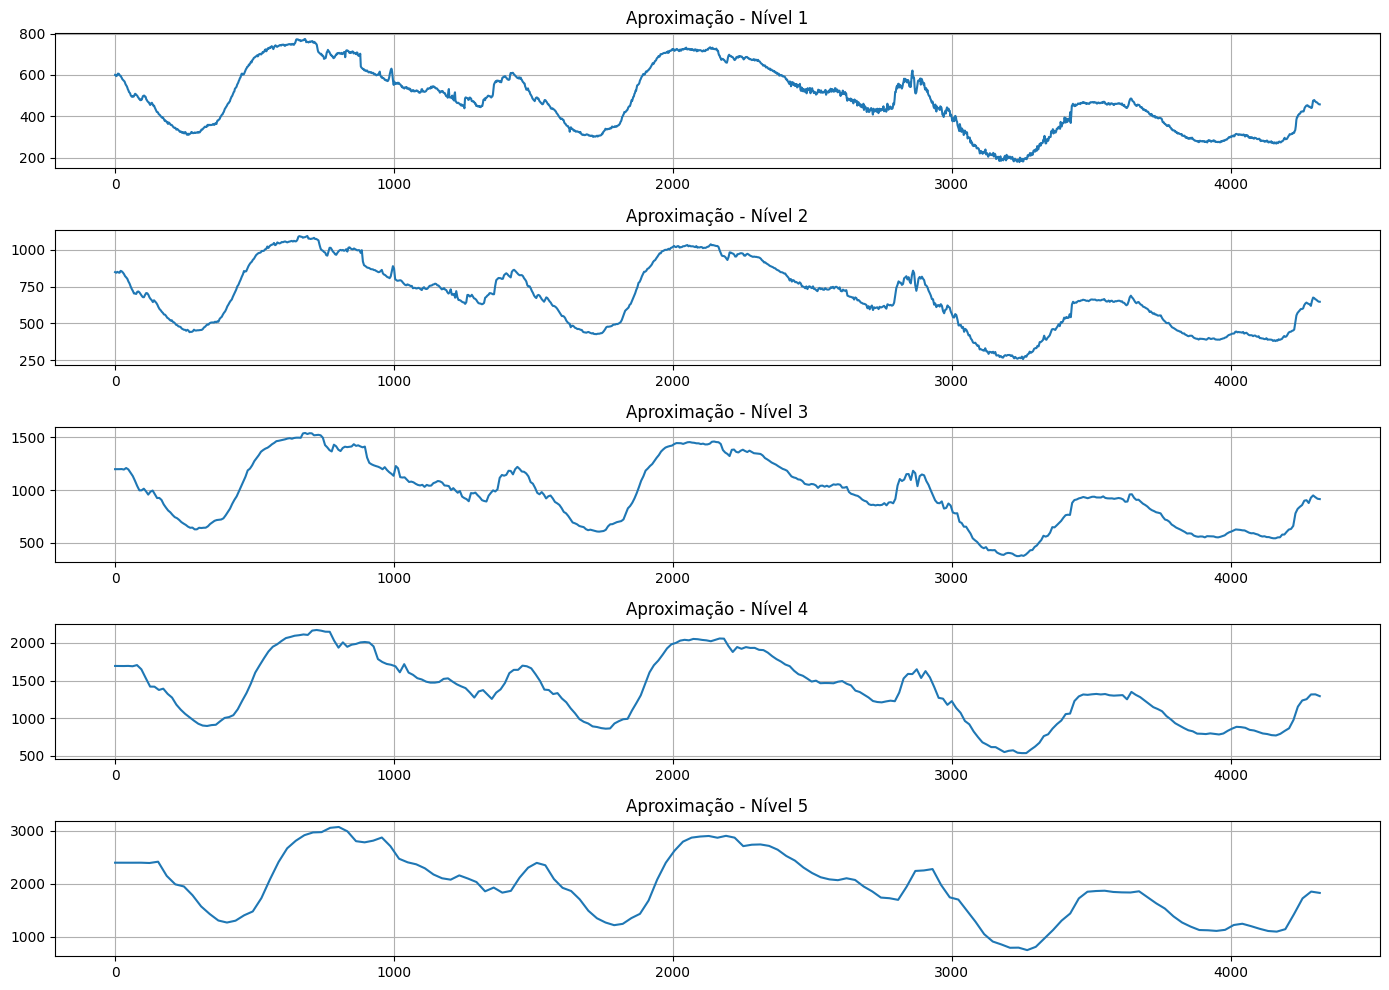

In [ ]:
# ============================================================
# Mostrando TODAS as aproximações intermediárias
# ============================================================

fig, axs = plt.subplots(nivel, 1, figsize=(14, 10))

for i in range(1, nivel + 1):

    coeffs_temp = pywt.wavedec(sinal, wavelet, level=i)

    A = coeffs_temp[0]

    xA = np.linspace(0, len(sinal), len(A))

    axs[i - 1].plot(xA, A)

    axs[i - 1].set_title(f'Aproximação - Nível {i}')
    axs[i - 1].grid()

plt.tight_layout()
plt.show()

In [ ]:
#Comente os resultados obtidos

### Decomposição Multinível (Exercício 4C)

A decomposição em 5 níveis utilizando a wavelet `db4` permitiu uma análise multirresolução eficaz:

1.  **Aproximação (cA5):** Atua como um filtro passa-baixas severo, capturando apenas a tendência de longo prazo (o 'esqueleto') do sinal original.
2.  **Detalhes (cD1 a cD5):** Os níveis mais finos (como cD1 e cD2) capturam as variações mais rápidas e ruídos de alta frequência. À medida que descemos para cD5, observamos variações mais lentas. Esta estrutura é ideal para compressão e remoção de ruído, pois permite isolar em quais escalas os eventos importantes ocorrem.

In [ ]:
#D)
import numpy as np
import matplotlib.pyplot as plt
import pywt

# ============================================================
# Função de threshold
# soft  -> suaviza coeficientes
# hard  -> zera coeficientes abaixo do limiar
# ============================================================

def aplicar_threshold(coeficientes, limiar, modo='soft'):

    novos_coef = [coeficientes[0]]  # aproximação

    for detalhe in coeficientes[1:]:

        detalhe_filtrado = pywt.threshold(
            detalhe,
            value=limiar,
            mode=modo
        )

        novos_coef.append(detalhe_filtrado)

    return novos_coef

In [ ]:
# ============================================================
# Definindo limiar
# ============================================================

limiar = 20

coef_filtrado = aplicar_threshold(
    coef,
    limiar,
    modo='soft'
)

# ============================================================
# Reconstruindo sinal filtrado
# ============================================================

sinal_reconstruido = pywt.waverec(
    coef_filtrado,
    wavelet
)

# Ajustando tamanho
sinal_reconstruido = sinal_reconstruido[:len(sinal)]

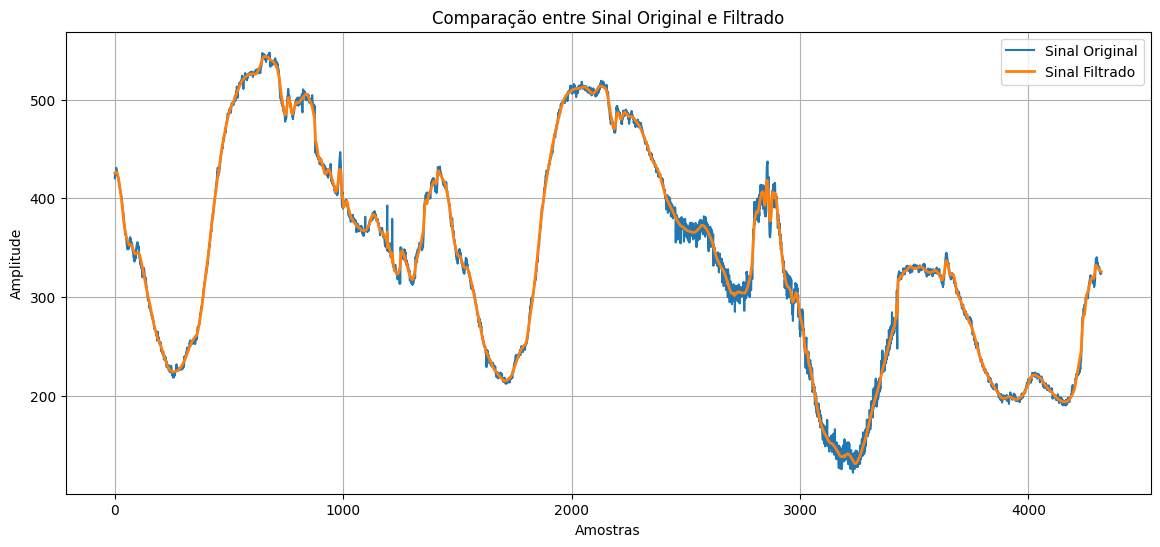

In [ ]:
# ============================================================
# Comparação sinal original x sinal filtrado
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(sinal, label='Sinal Original')
plt.plot(sinal_reconstruido,
         label='Sinal Filtrado',
         linewidth=2)

plt.title('Comparação entre Sinal Original e Filtrado')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')

plt.legend()
plt.grid()

plt.show()

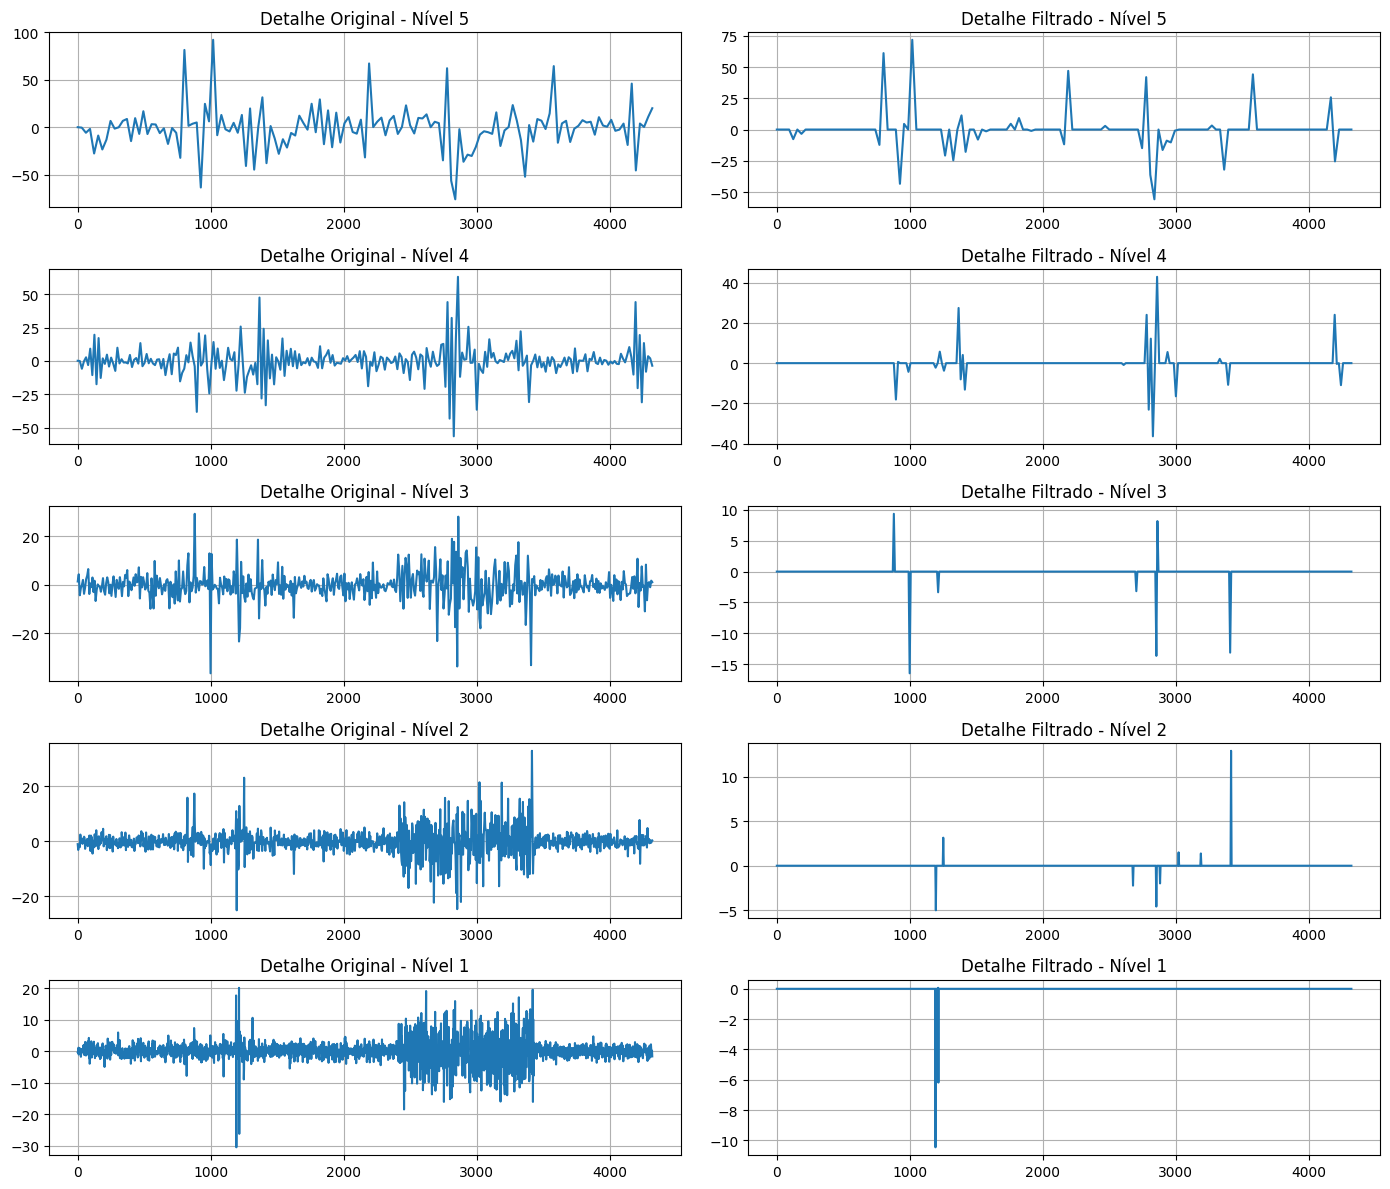

In [ ]:
# ============================================================
# Comparação dos coeficientes de detalhe
# ============================================================

fig, axs = plt.subplots(nivel, 2, figsize=(14, 12))

for i in range(nivel):

    nivel_atual = nivel - i

    detalhe_original = coef[i + 1]
    detalhe_filtrado = coef_filtrado[i + 1]

    x1 = np.linspace(0, len(sinal), len(detalhe_original))
    x2 = np.linspace(0, len(sinal), len(detalhe_filtrado))

    # Original
    axs[i,0].plot(x1, detalhe_original)
    axs[i,0].set_title(f'Detalhe Original - Nível {nivel_atual}')
    axs[i,0].grid()

    # Filtrado
    axs[i,1].plot(x2, detalhe_filtrado)
    axs[i,1].set_title(f'Detalhe Filtrado - Nível {nivel_atual}')
    axs[i,1].grid()

plt.tight_layout()
plt.show()

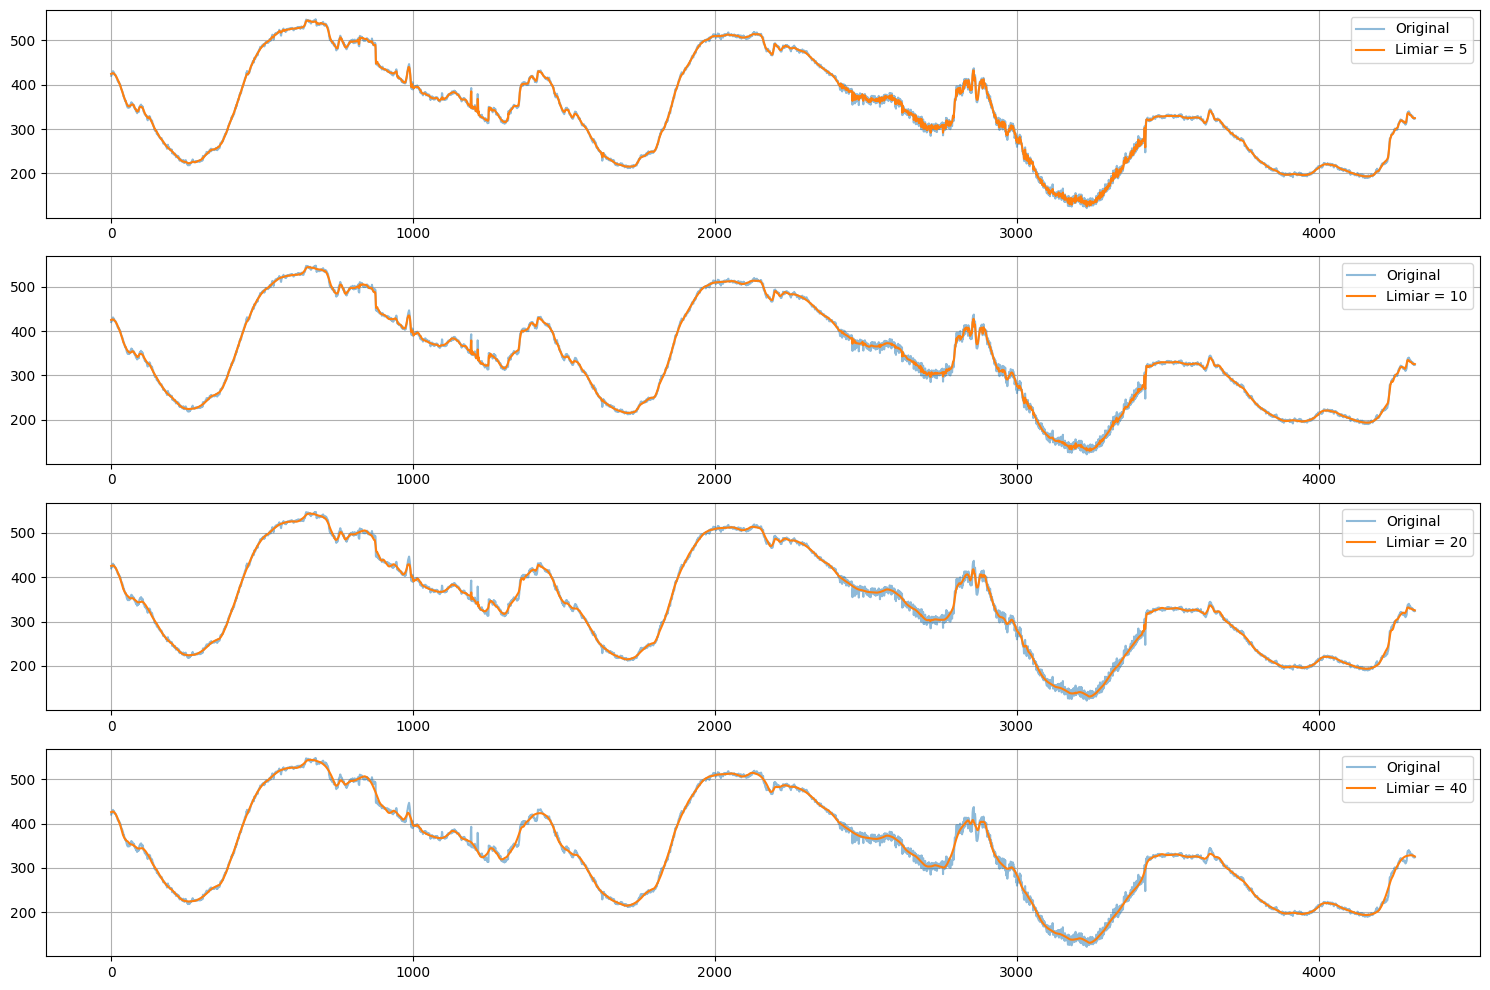

In [ ]:
# ============================================================
# Comparando diferentes limiares
# ============================================================

limiares = [5, 10, 20, 40]

plt.figure(figsize=(15,10))

for i, T in enumerate(limiares):

    coef_temp = aplicar_threshold(
        coef,
        T,
        modo='soft'
    )

    sinal_temp = pywt.waverec(coef_temp, wavelet)

    sinal_temp = sinal_temp[:len(sinal)]

    plt.subplot(len(limiares),1,i+1)

    plt.plot(sinal, alpha=0.5, label='Original')
    plt.plot(sinal_temp,
             label=f'Limiar = {T}')

    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# comente os resultados obtidos

### Eficácia do Denoising via Wavelet Thresholding (Exercício 4D)

1.  **Soft Thresholding:** A aplicação do limiar nos coeficientes de detalhe removeu efetivamente as oscilações de pequena amplitude que representam o ruído.
2.  **Preservação de Transientes:** Ao contrário de um filtro passa-baixas comum da FFT (que 'borraria' picos), a filtragem por Wavelet conseguiu manter a estrutura das transições bruscas do sinal `leleccum`.
3.  **Escolha do Limiar:** Observamos que limiares muito baixos (ex: 5) mantêm muito ruído, enquanto limiares excessivamente altos (ex: 40) começam a distorcer a amplitude real das componentes importantes do sinal original.

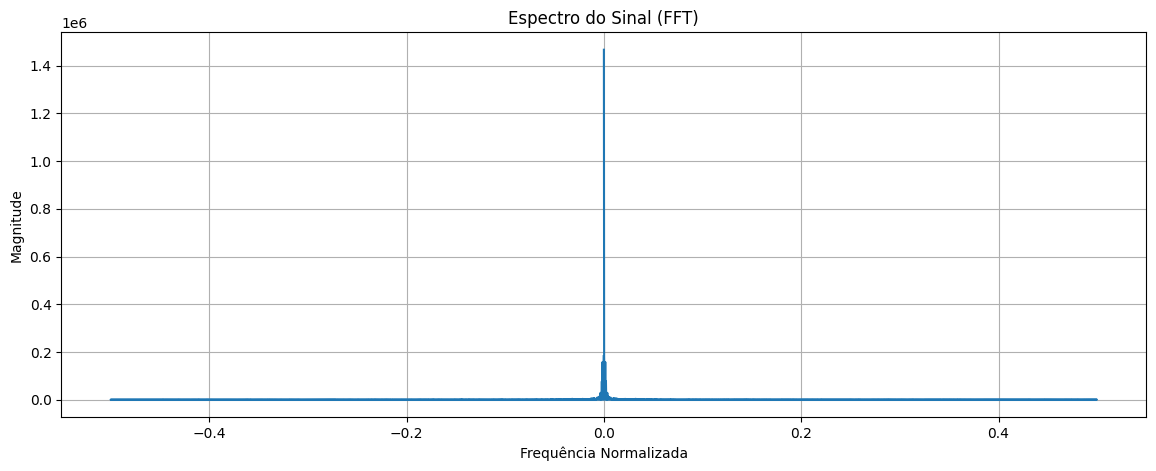

In [ ]:
#E)
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Calculando a FFT do sinal
# ============================================================

fft_sinal = np.fft.fft(sinal)

# Frequências
frequencias = np.fft.fftfreq(len(sinal))

# ============================================================
# Magnitude do espectro
# ============================================================

magnitude = np.abs(fft_sinal)

plt.figure(figsize=(14,5))

plt.plot(frequencias, magnitude)

plt.title('Espectro do Sinal (FFT)')
plt.xlabel('Frequência Normalizada')
plt.ylabel('Magnitude')

plt.grid()

plt.show()

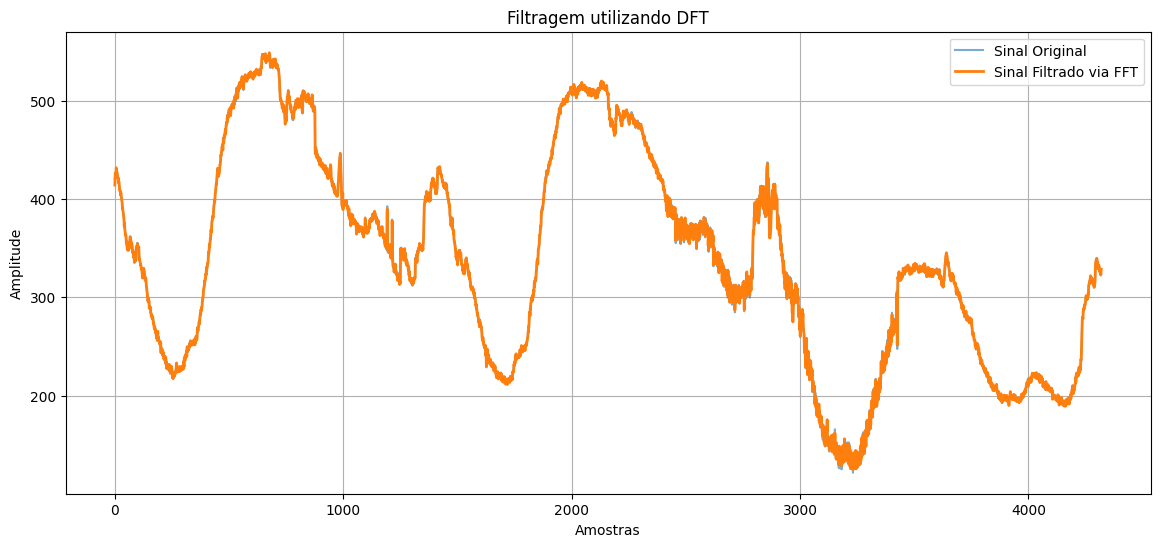

In [ ]:
# ============================================================
# Aplicando threshold na FFT
# ============================================================

limiar_fft = 200

fft_filtrada = fft_sinal.copy()

# Zera componentes abaixo do limiar
fft_filtrada[magnitude < limiar_fft] = 0

# ============================================================
# Reconstruindo sinal via IFFT
# ============================================================

sinal_fft_filtrado = np.fft.ifft(fft_filtrada)

# Pegando apenas parte real
sinal_fft_filtrado = np.real(sinal_fft_filtrado)

# ============================================================
# Comparando sinais
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(sinal,
         label='Sinal Original',
         alpha=0.6)

plt.plot(sinal_fft_filtrado,
         label='Sinal Filtrado via FFT',
         linewidth=2)

plt.title('Filtragem utilizando DFT')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')

plt.legend()
plt.grid()

plt.show()

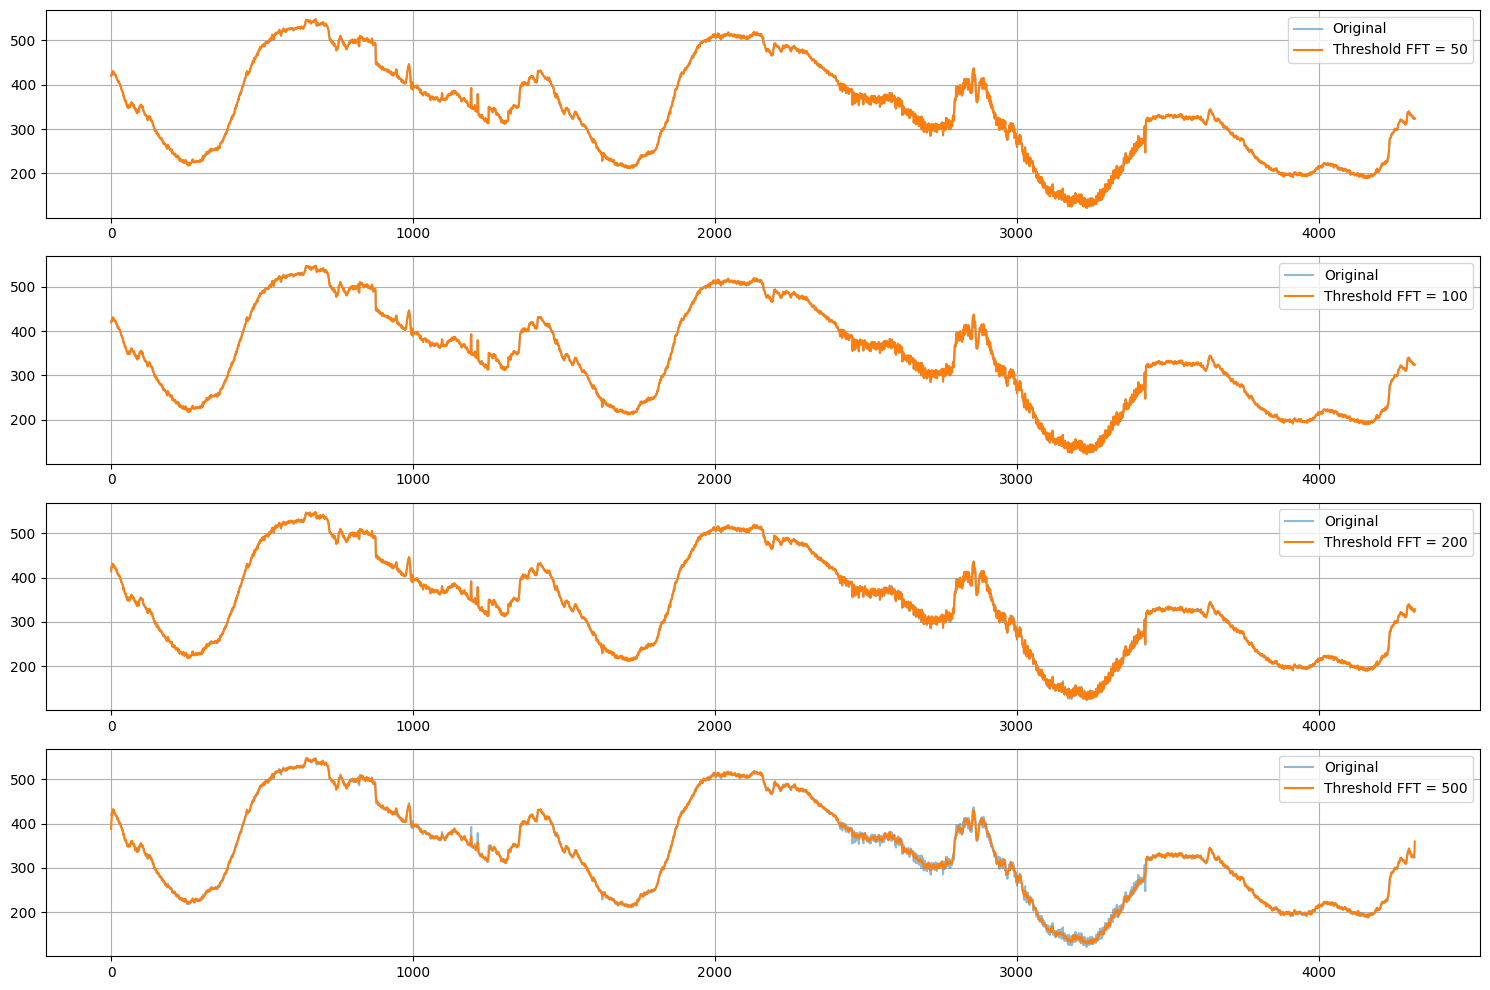

In [ ]:
# ============================================================
# Comparando diferentes thresholds
# ============================================================

limiares_fft = [50, 100, 200, 500]

plt.figure(figsize=(15,10))

for i, T in enumerate(limiares_fft):

    fft_temp = fft_sinal.copy()

    fft_temp[magnitude < T] = 0

    sinal_temp = np.real(np.fft.ifft(fft_temp))

    plt.subplot(len(limiares_fft),1,i+1)

    plt.plot(sinal,
             alpha=0.5,
             label='Original')

    plt.plot(sinal_temp,
             label=f'Threshold FFT = {T}')

    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

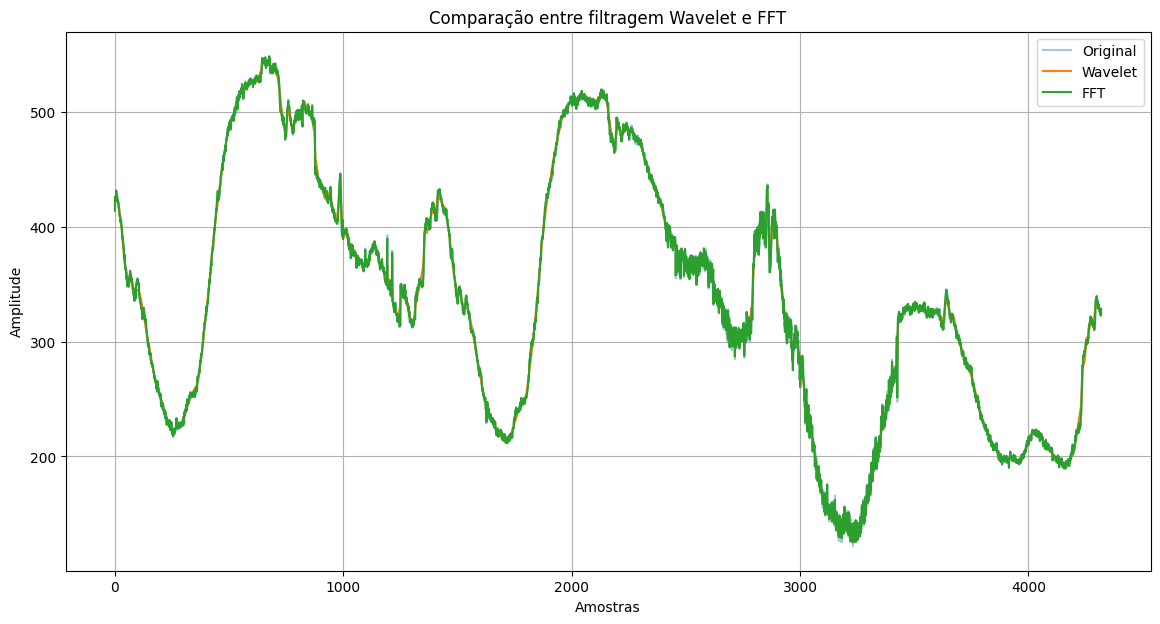

In [ ]:
# ============================================================
# Comparação: Wavelet x FFT
# ============================================================

plt.figure(figsize=(14,7))

plt.plot(sinal,
         label='Original',
         alpha=0.4)

plt.plot(sinal_reconstruido,
         label='Wavelet')

plt.plot(sinal_fft_filtrado,
         label='FFT')

plt.title('Comparação entre filtragem Wavelet e FFT')

plt.xlabel('Amostras')
plt.ylabel('Amplitude')

plt.legend()
plt.grid()

plt.show()